<a href="https://www.kaggle.com/code/lalit7881/food-delivery-orders-eta-logistics-76?scriptVersionId=343698993" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
# Imports and Configuration
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Configure matplotlib
plt.switch_backend('Agg')
%matplotlib inline

from pathlib import Path

# Use our helper function to resolve data file paths
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Print a simple message to confirm configuration
print('Imports and configurations loaded successfully.')


/kaggle/input/datasets/razanihababdellatif/food-delivery-orders-and-eta-logistics-dataset/food_delivery_orders_dataset.csv
Imports and configurations loaded successfully.


## Loading dataset

In [2]:
file_path = resolve_data_file(file_name='food_delivery_orders_dataset.csv', suffixes=['.csv'])

# Load the dataset
df = pd.read_csv(file_path, delimiter=',', encoding='ascii')

In [3]:
# Quick overview of the data structure
print('Data loaded successfully. DataFrame shape:', df.shape)

# Convert date columns to datetime
for col in ['order_timestamp', 'order_date']:
    if col in df.columns:
        try:
            df[col] = pd.to_datetime(df[col])
        except Exception as e:
            print(f'Error parsing {col}:', e)

# Display first few rows
df.head()

Data loaded successfully. DataFrame shape: (50000, 37)


,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,ORD_000001,CUS_00001,RES_0008,DRV_0075,2025-10-05 15:54:00,2025-10-05,15,Sunday,1,City_C,...,Medium,14,4.4,25,25,29.0,0.0,Completed,NaN,4.6
1,ORD_000002,CUS_00013,RES_0024,DRV_0131,2025-10-01 20:00:00,2025-10-01,20,Wednesday,0,City_A,...,High,44,4.7,12,20,24.0,0.0,Completed,NaN,5.0
2,ORD_000003,CUS_00049,RES_0013,DRV_0087,2025-10-07 18:24:00,2025-10-07,18,Tuesday,0,City_C,...,High,1,5.0,11,63,72.0,1.0,Completed,NaN,3.6
3,ORD_000004,CUS_00007,RES_0001,DRV_0177,2025-10-30 16:54:00,2025-10-30,16,Thursday,0,City_A,...,Low,50,4.3,12,23,31.0,1.0,Completed,NaN,4.1
4,ORD_000005,CUS_00325,RES_0029,DRV_0114,2025-10-15 18:34:00,2025-10-15,18,Wednesday,0,City_B,...,Medium,21,4.0,9,32,42.0,1.0,Completed,NaN,3.9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   order_id                             50000 non-null  object        
 1   customer_id                          50000 non-null  object        
 2   restaurant_id                        50000 non-null  object        
 3   driver_id                            50000 non-null  object        
 4   order_timestamp                      50000 non-null  datetime64[ns]
 5   order_date                           50000 non-null  datetime64[ns]
 6   order_hour                           50000 non-null  int64         
 7   day_of_week                          50000 non-null  object        
 8   is_weekend                           50000 non-null  int64         
 9   city                                 50000 non-null  object        
 10  delivery_a

In [5]:
df.describe()

,order_timestamp,order_date,order_hour,is_weekend,customer_age,restaurant_rating,items_count,subtotal,discount_percent,tax_amount,...,order_total,tip_amount,distance_km,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,customer_rating
count,50000,50000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,49132.000000,50000.000000,50000.0000,50000.000000,50000.000000,50000.000000,49132.000000,49132.000000,49132.000000
mean,2025-10-16 04:28:15.081600,2025-10-15 13:30:58.752000256,14.465900,0.26712,27.686580,4.207956,2.91002,30.897938,4.495700,4.128796,...,38.169501,1.610076,4.730632,29.7332,4.495062,15.549600,30.950580,35.152365,0.365709,4.295946
min,2025-10-01 00:00:00,2025-10-01 00:00:00,0.000000,0.00000,18.000000,2.800000,1.00000,5.100000,0.000000,0.570000,...,4.870000,0.000000,0.800000,1.0000,3.200000,5.000000,8.000000,10.000000,0.000000,1.800000
25%,2025-10-08 15:00:30,2025-10-08 00:00:00,11.000000,0.00000,21.000000,3.900000,1.00000,13.100000,0.000000,1.730000,...,17.430000,0.000000,2.800000,14.0000,4.300000,10.000000,22.000000,25.000000,0.000000,4.000000
50%,2025-10-16 09:24:00,2025-10-16 00:00:00,14.000000,0.00000,27.000000,4.200000,2.00000,22.825000,0.000000,2.890000,...,28.350000,0.000000,4.100000,29.0000,4.500000,14.000000,28.000000,33.000000,0.000000,4.400000
75%,2025-10-23 16:52:15,2025-10-23 00:00:00,19.000000,1.00000,33.000000,4.600000,4.00000,40.120000,10.000000,5.390000,...,48.660000,2.280000,5.900000,44.0000,4.800000,19.000000,37.000000,42.000000,1.000000,4.700000
max,2025-10-30 23:59:00,2025-10-30 00:00:00,23.000000,1.00000,55.000000,5.000000,10.00000,362.980000,20.000000,50.820000,...,443.210000,53.650000,20.000000,60.0000,5.000000,73.000000,128.000000,172.000000,1.000000,5.000000
std,NaN,NaN,5.231155,0.44246,7.537796,0.450977,2.02907,27.068965,6.430008,3.636275,...,31.054669,2.878464,2.780190,17.4052,0.349198,7.360099,12.825519,14.701154,0.481633,0.530947


In [6]:
df.isnull().sum()

order_id                                   0
customer_id                                0
restaurant_id                              0
driver_id                                  0
order_timestamp                            0
order_date                                 0
order_hour                                 0
day_of_week                                0
is_weekend                                 0
city                                       0
delivery_area                              0
customer_age                               0
customer_type                              0
restaurant_type                            0
restaurant_primary_category                0
restaurant_rating                          0
items_count                                0
subtotal                                   0
discount_percent                           0
tax_amount                                 0
service_fee                                0
delivery_fee                               0
order_tota

In [7]:
df.dtypes

order_id                                       object
customer_id                                    object
restaurant_id                                  object
driver_id                                      object
order_timestamp                        datetime64[ns]
order_date                             datetime64[ns]
order_hour                                      int64
day_of_week                                    object
is_weekend                                      int64
city                                           object
delivery_area                                  object
customer_age                                    int64
customer_type                                  object
restaurant_type                                object
restaurant_primary_category                    object
restaurant_rating                             float64
items_count                                     int64
subtotal                                      float64
discount_percent            

In [8]:
df.shape

(50000, 37)

In [9]:
df.columns

Index(['order_id', 'customer_id', 'restaurant_id', 'driver_id',
       'order_timestamp', 'order_date', 'order_hour', 'day_of_week',
       'is_weekend', 'city', 'delivery_area', 'customer_age', 'customer_type',
       'restaurant_type', 'restaurant_primary_category', 'restaurant_rating',
       'items_count', 'subtotal', 'discount_percent', 'tax_amount',
       'service_fee', 'delivery_fee', 'order_total', 'payment_method',
       'tip_amount', 'distance_km', 'weather', 'traffic_level',
       'delivery_partner_experience_months', 'delivery_partner_rating',
       'restaurant_preparation_time_minutes',
       'estimated_delivery_time_minutes', 'actual_delivery_time_minutes',
       'late_delivery', 'order_status', 'cancellation_reason',
       'customer_rating'],
      dtype='object')

## EDA

Dataset Shape: (50000, 37)

Column Names:
['order_id', 'customer_id', 'restaurant_id', 'driver_id', 'order_timestamp', 'order_date', 'order_hour', 'day_of_week', 'is_weekend', 'city', 'delivery_area', 'customer_age', 'customer_type', 'restaurant_type', 'restaurant_primary_category', 'restaurant_rating', 'items_count', 'subtotal', 'discount_percent', 'tax_amount', 'service_fee', 'delivery_fee', 'order_total', 'payment_method', 'tip_amount', 'distance_km', 'weather', 'traffic_level', 'delivery_partner_experience_months', 'delivery_partner_rating', 'restaurant_preparation_time_minutes', 'estimated_delivery_time_minutes', 'actual_delivery_time_minutes', 'late_delivery', 'order_status', 'cancellation_reason', 'customer_rating']

First 5 Rows:


,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,ORD_000001,CUS_00001,RES_0008,DRV_0075,2025-10-05 15:54:00,2025-10-05,15,Sunday,1,City_C,...,Medium,14,4.4,25,25,29.0,0.0,Completed,NaN,4.6
1,ORD_000002,CUS_00013,RES_0024,DRV_0131,2025-10-01 20:00:00,2025-10-01,20,Wednesday,0,City_A,...,High,44,4.7,12,20,24.0,0.0,Completed,NaN,5.0
2,ORD_000003,CUS_00049,RES_0013,DRV_0087,2025-10-07 18:24:00,2025-10-07,18,Tuesday,0,City_C,...,High,1,5.0,11,63,72.0,1.0,Completed,NaN,3.6
3,ORD_000004,CUS_00007,RES_0001,DRV_0177,2025-10-30 16:54:00,2025-10-30,16,Thursday,0,City_A,...,Low,50,4.3,12,23,31.0,1.0,Completed,NaN,4.1
4,ORD_000005,CUS_00325,RES_0029,DRV_0114,2025-10-15 18:34:00,2025-10-15,18,Wednesday,0,City_B,...,Medium,21,4.0,9,32,42.0,1.0,Completed,NaN,3.9



========== DATA INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 37 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   order_id                             50000 non-null  object        
 1   customer_id                          50000 non-null  object        
 2   restaurant_id                        50000 non-null  object        
 3   driver_id                            50000 non-null  object        
 4   order_timestamp                      50000 non-null  datetime64[ns]
 5   order_date                           50000 non-null  datetime64[ns]
 6   order_hour                           50000 non-null  int64         
 7   day_of_week                          50000 non-null  object        
 8   is_weekend                           50000 non-null  int64         
 9   city                                 50000 

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,50000,50000,ORD_049984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,50000,4979,CUS_00001,4510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restaurant_id,50000,250,RES_0001,8837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
driver_id,50000,200,DRV_0066,315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_timestamp,50000,NaN,NaN,NaN,2025-10-16 04:28:15.081600,2025-10-01 00:00:00,2025-10-08 15:00:30,2025-10-16 09:24:00,2025-10-23 16:52:15,2025-10-30 23:59:00,NaN
order_date,50000,NaN,NaN,NaN,2025-10-15 13:30:58.752000256,2025-10-01 00:00:00,2025-10-08 00:00:00,2025-10-16 00:00:00,2025-10-23 00:00:00,2025-10-30 00:00:00,NaN
order_hour,50000.0,NaN,NaN,NaN,14.4659,0.0,11.0,14.0,19.0,23.0,5.231155
day_of_week,50000,7,Thursday,8472,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_weekend,50000.0,NaN,NaN,NaN,0.26712,0.0,0.0,0.0,1.0,1.0,0.44246
city,50000,4,City_A,19888,NaN,NaN,NaN,NaN,NaN,NaN,NaN


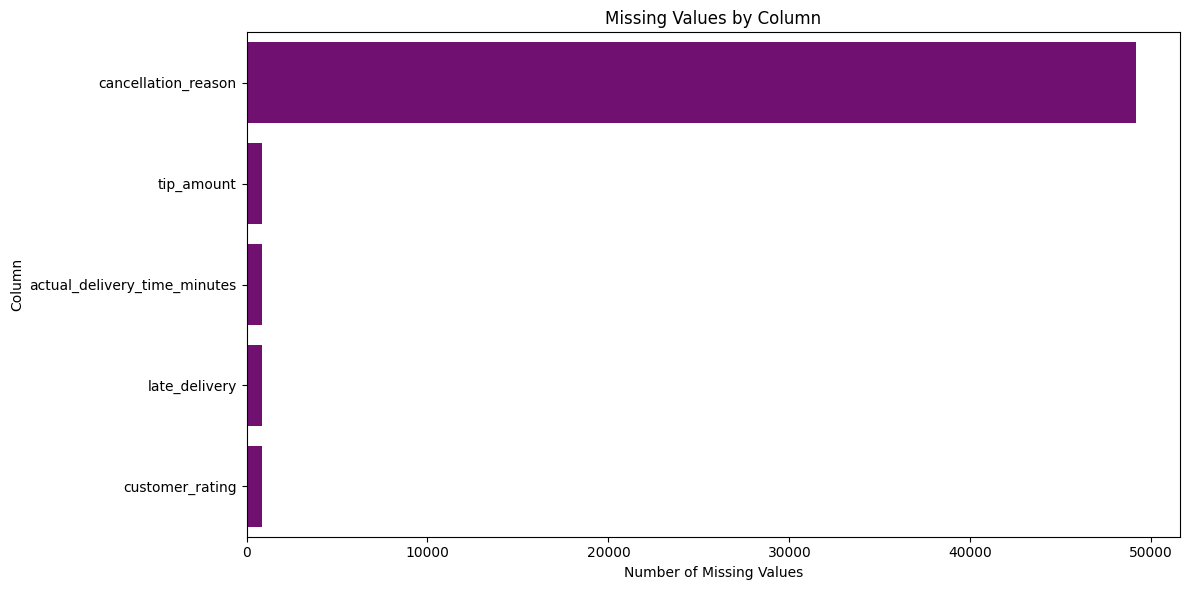

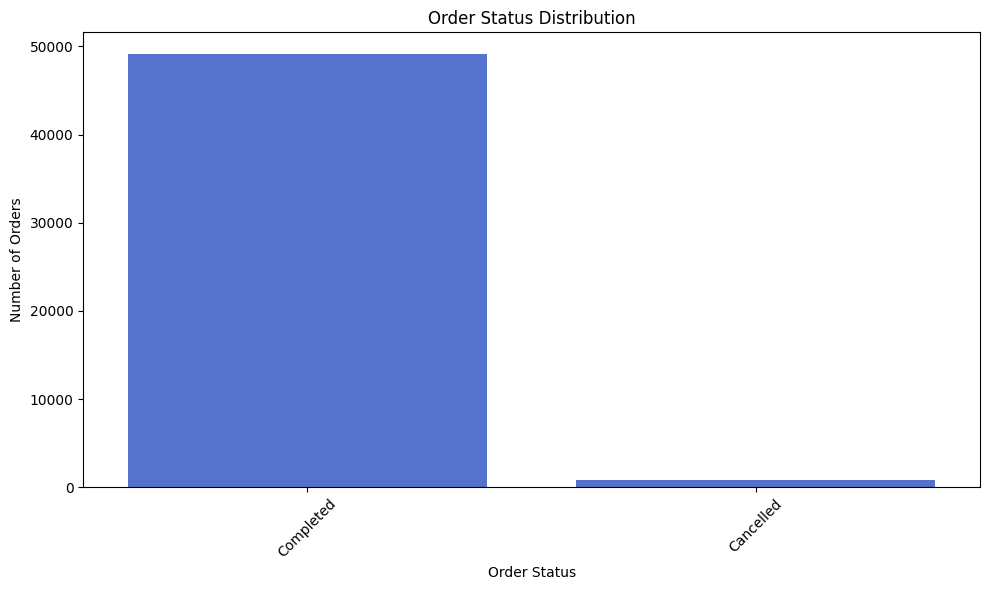

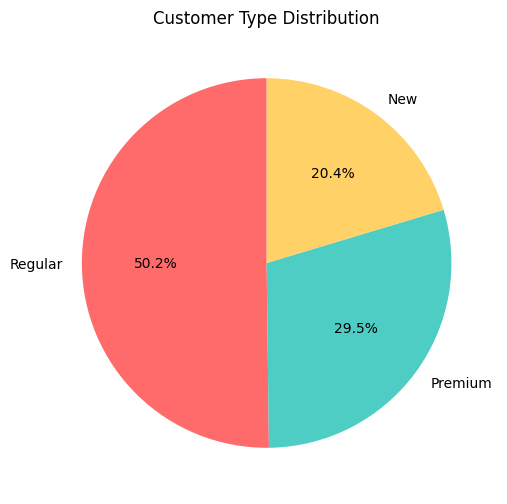

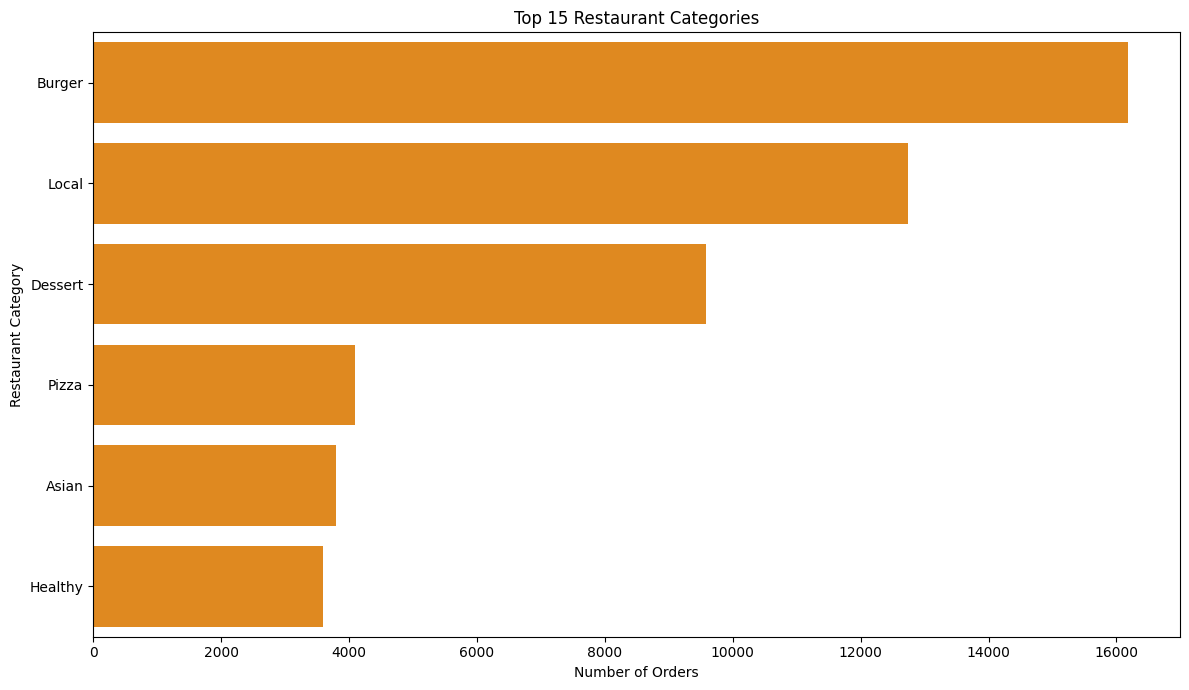

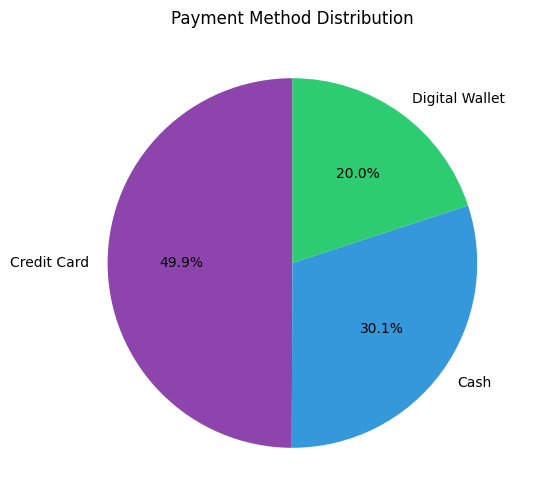

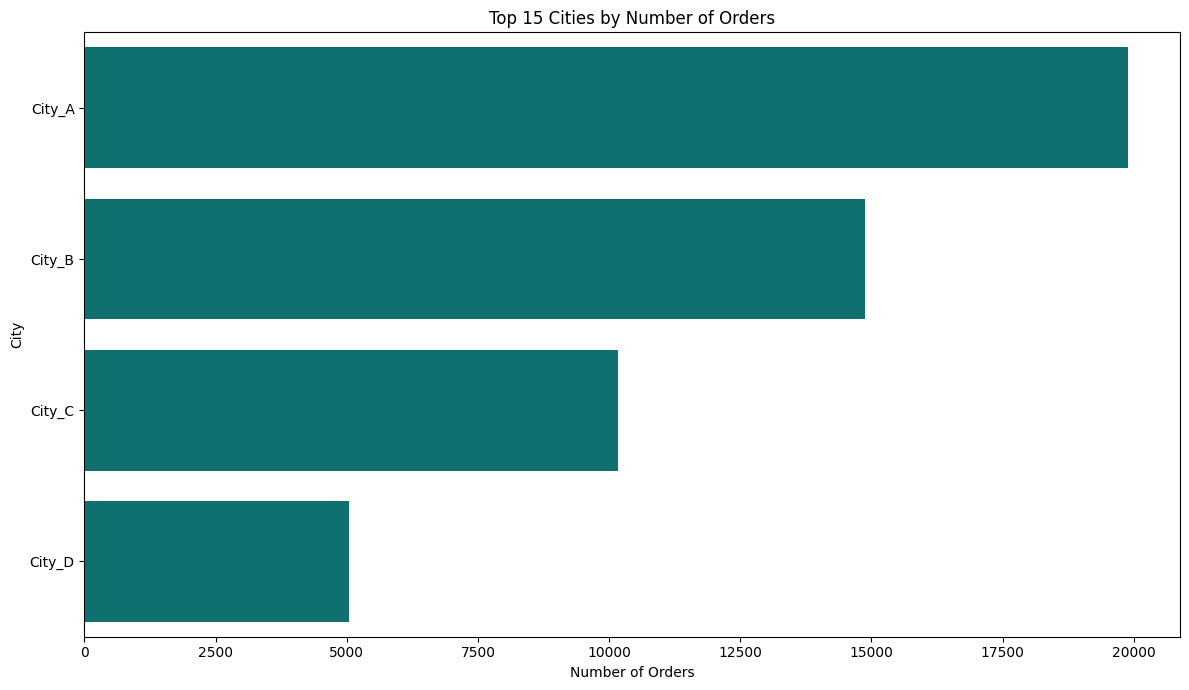

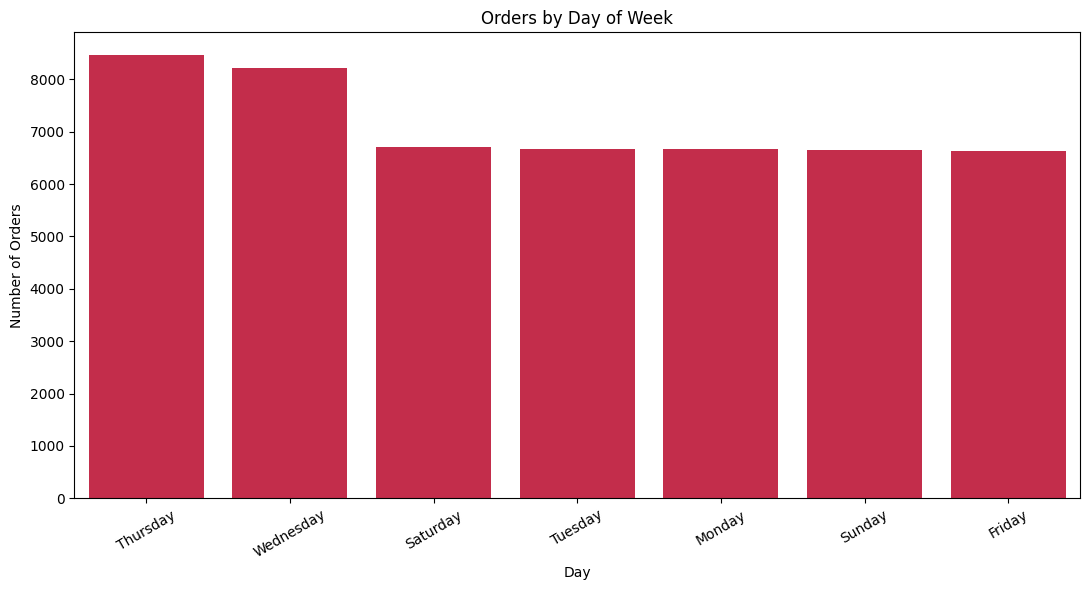

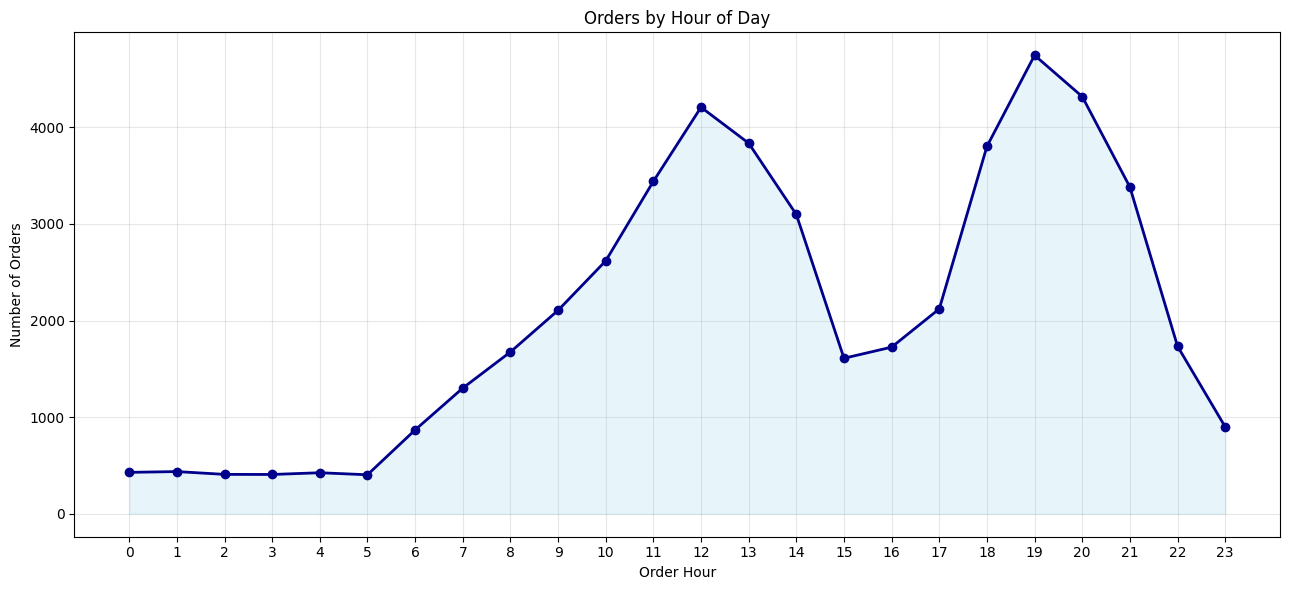

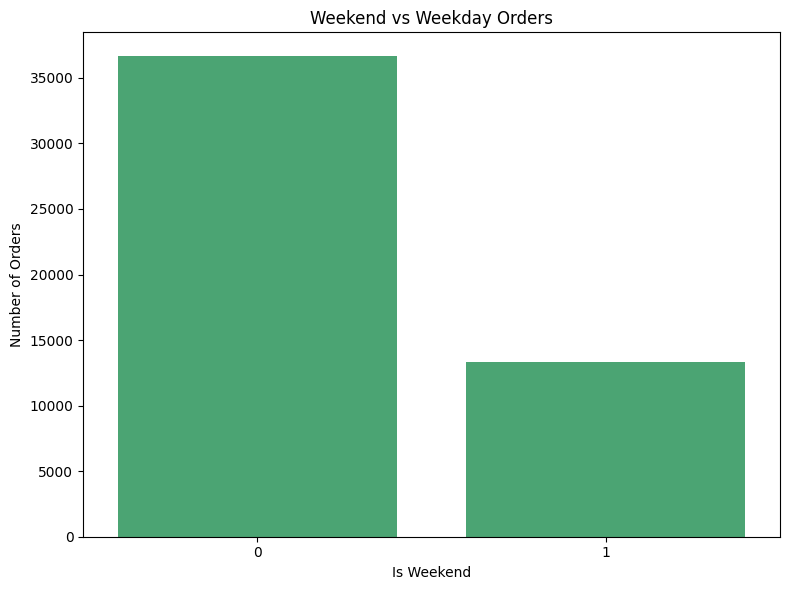

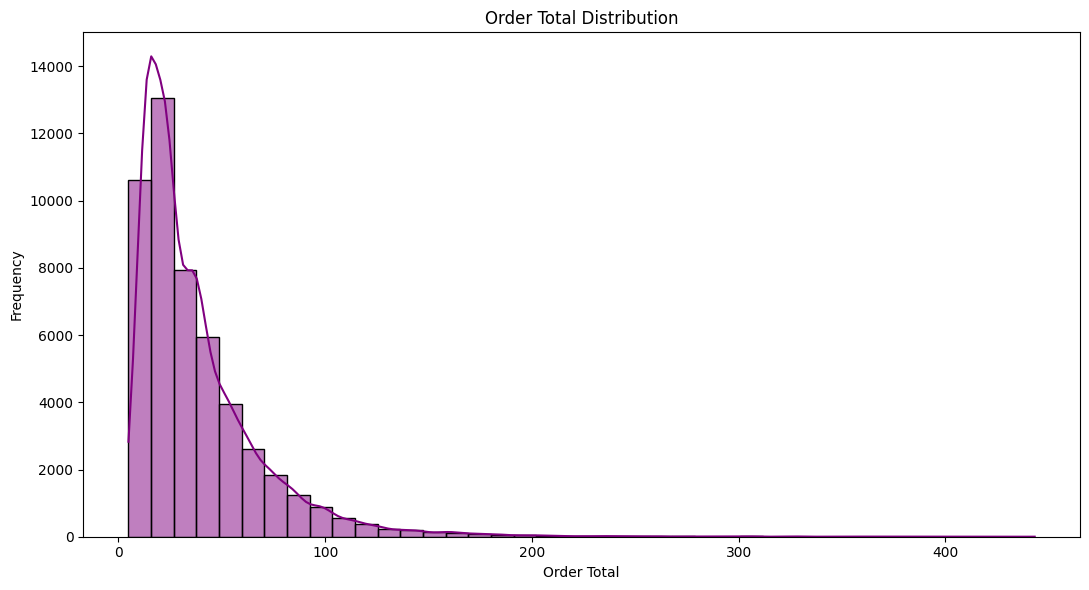

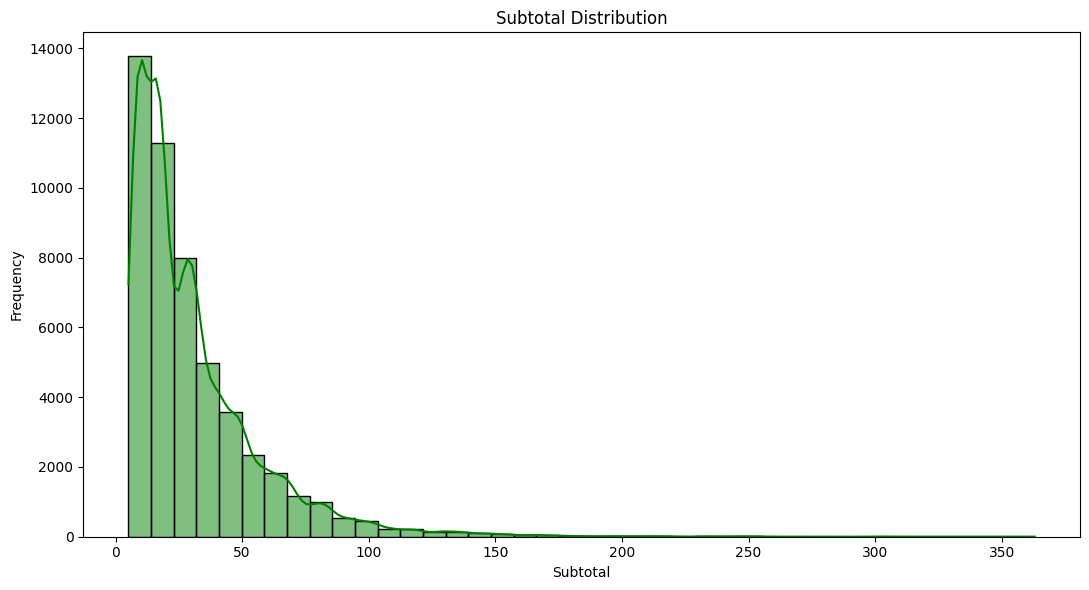

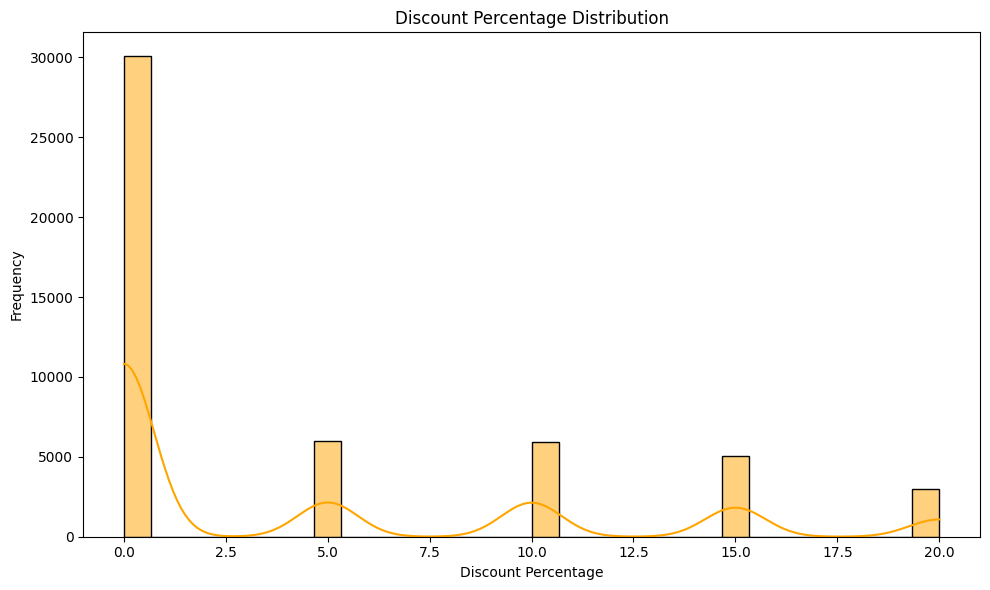

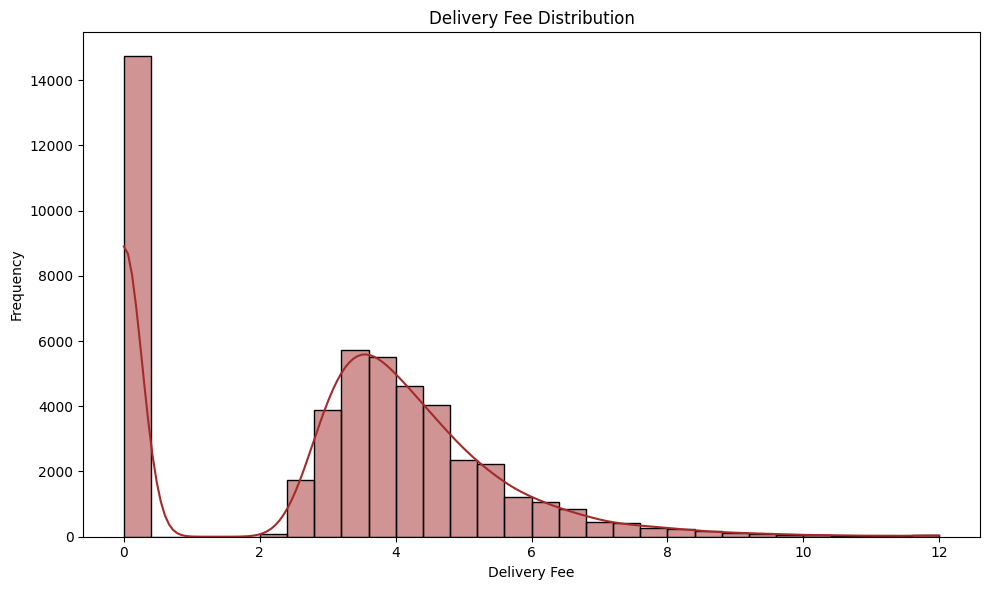

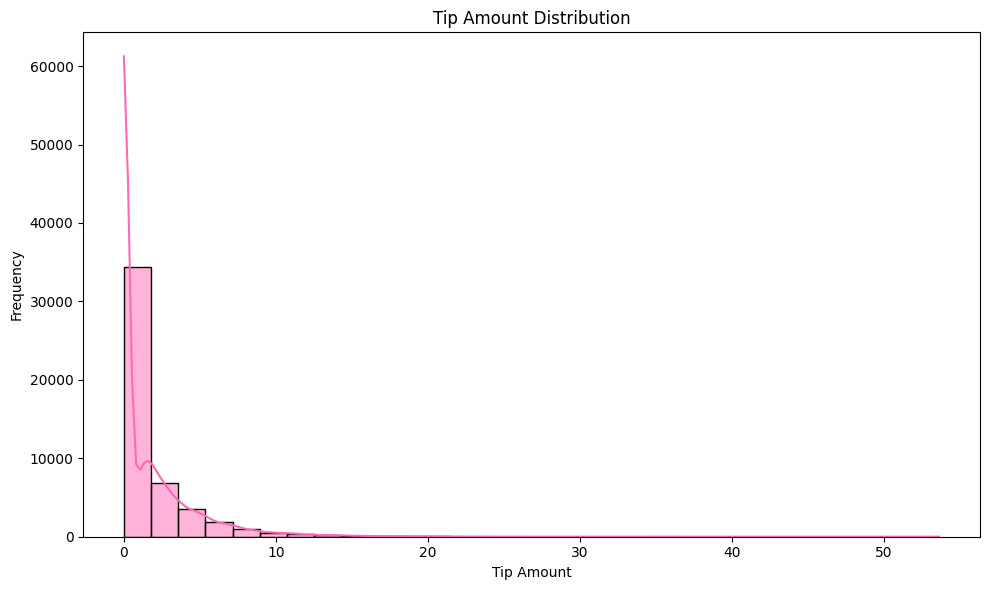

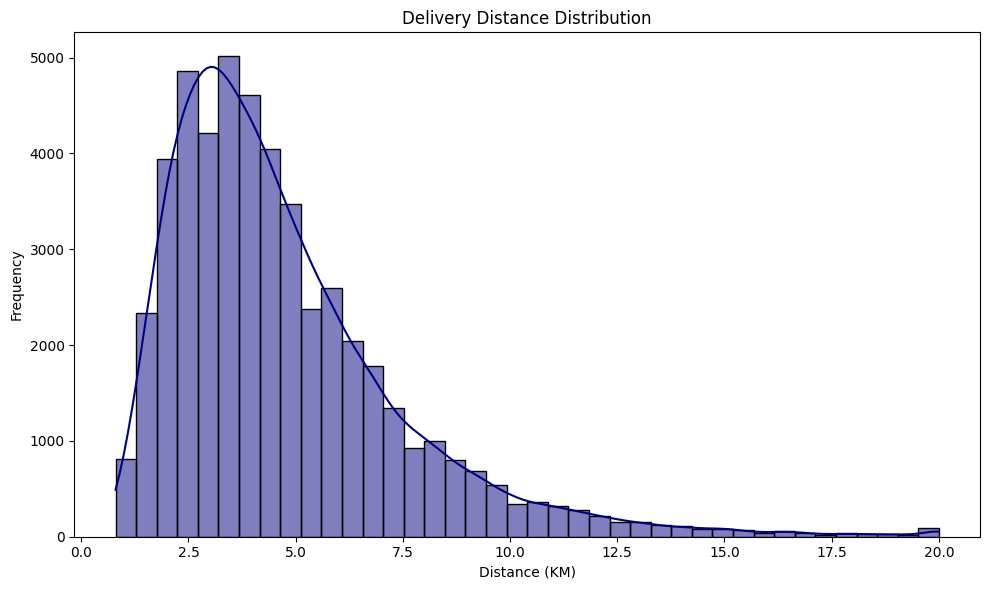

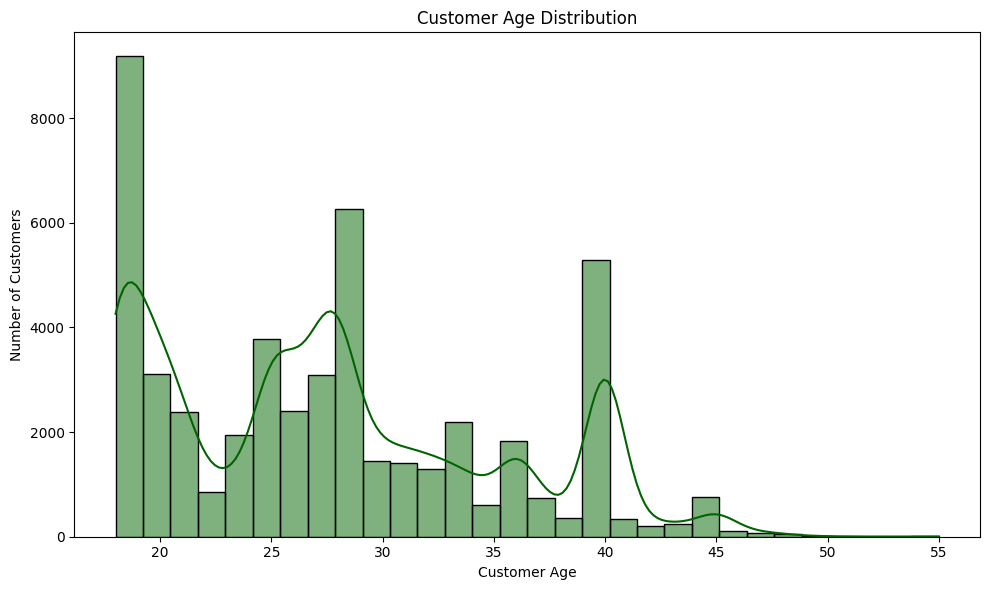

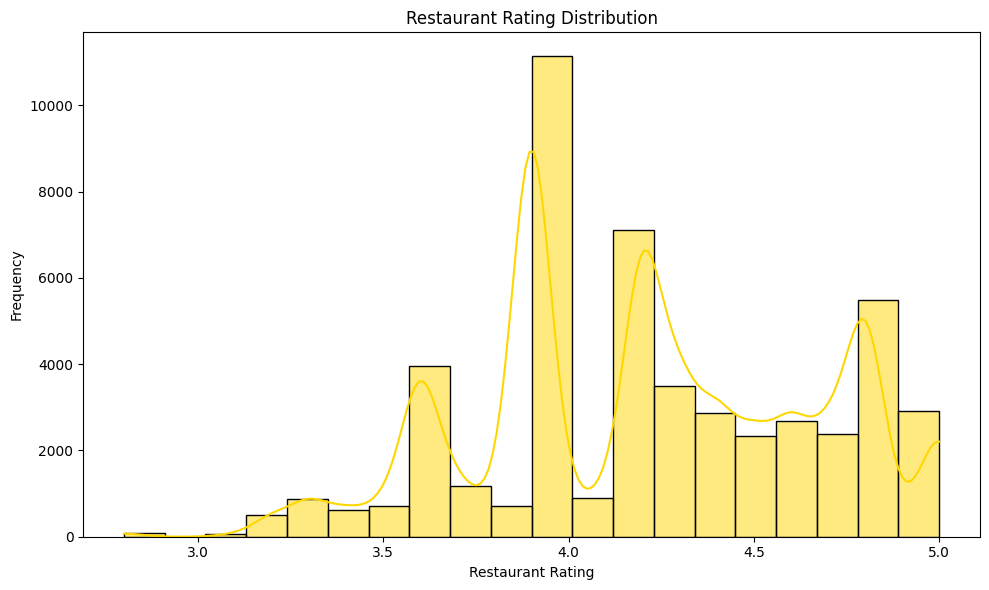

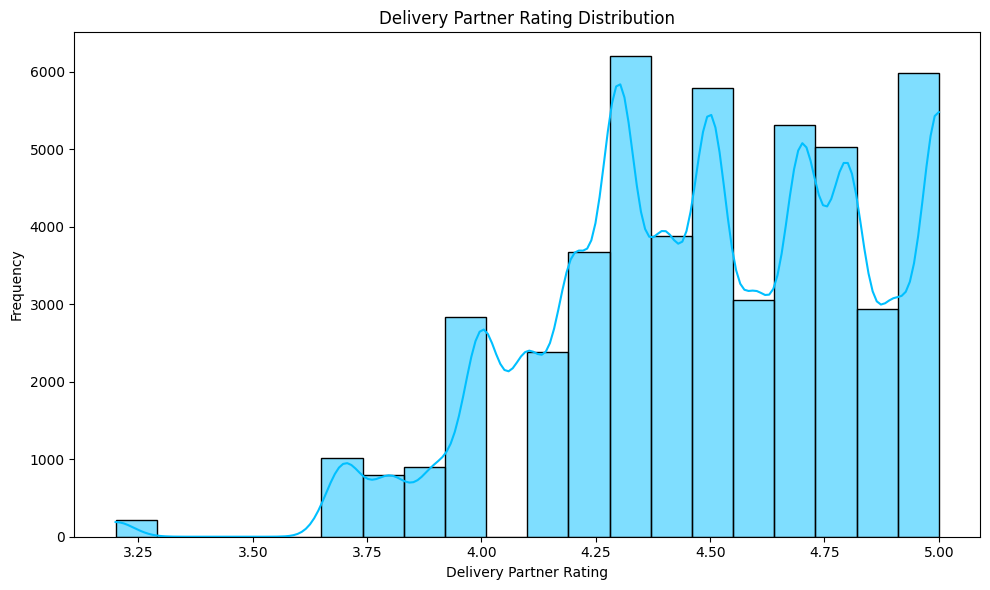

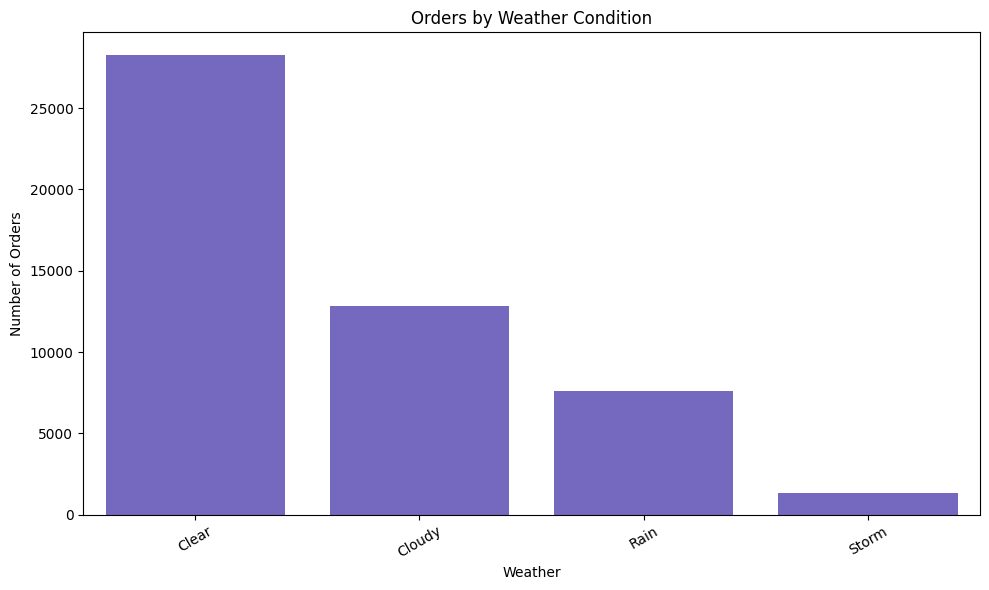

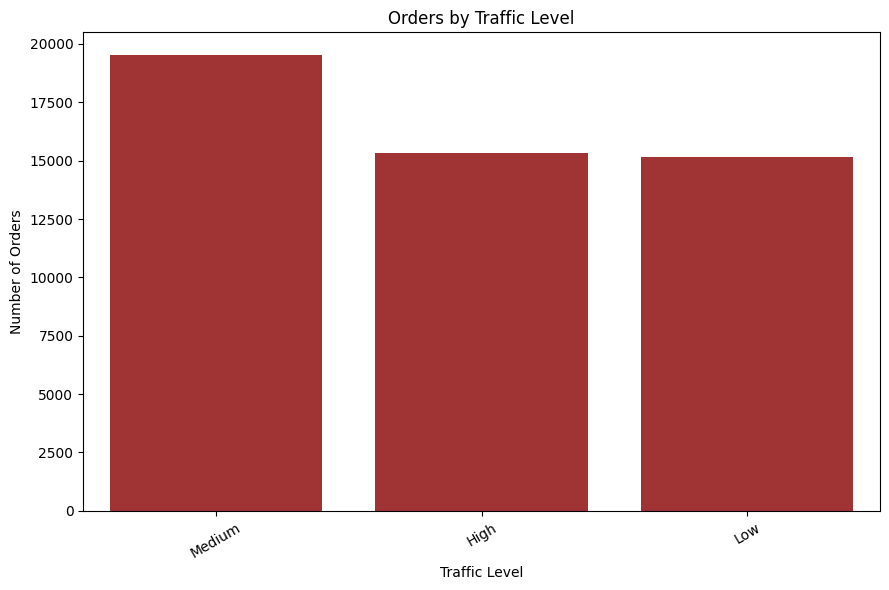

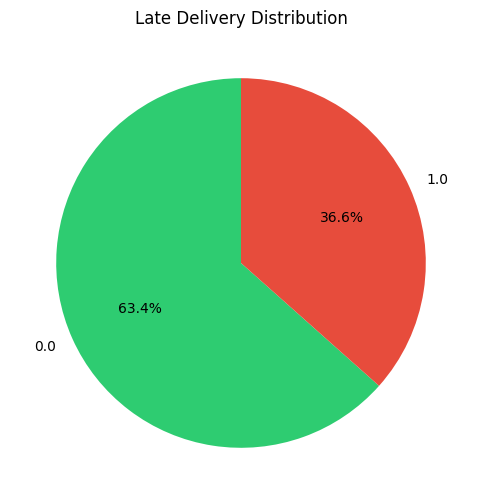

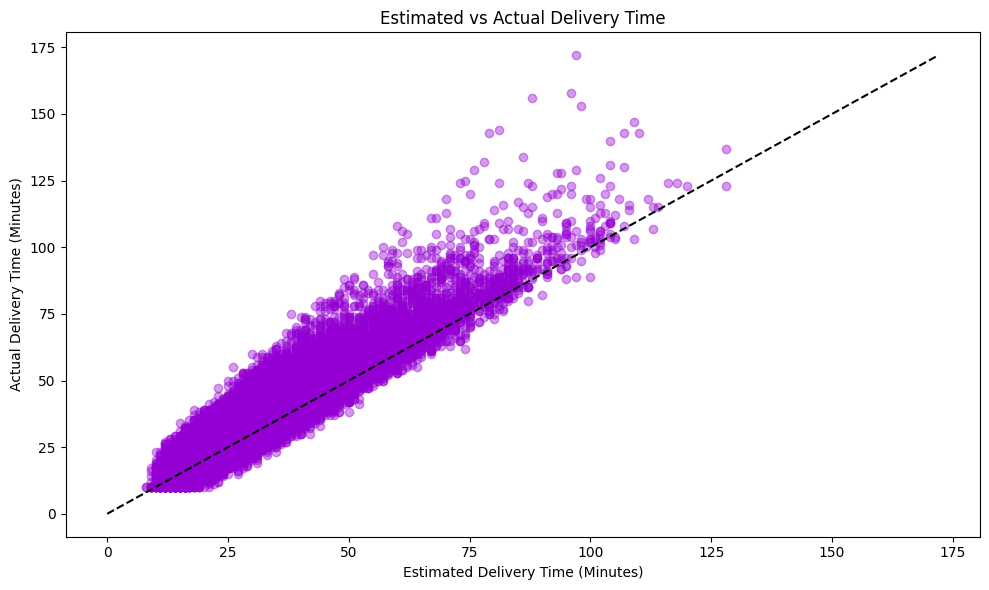

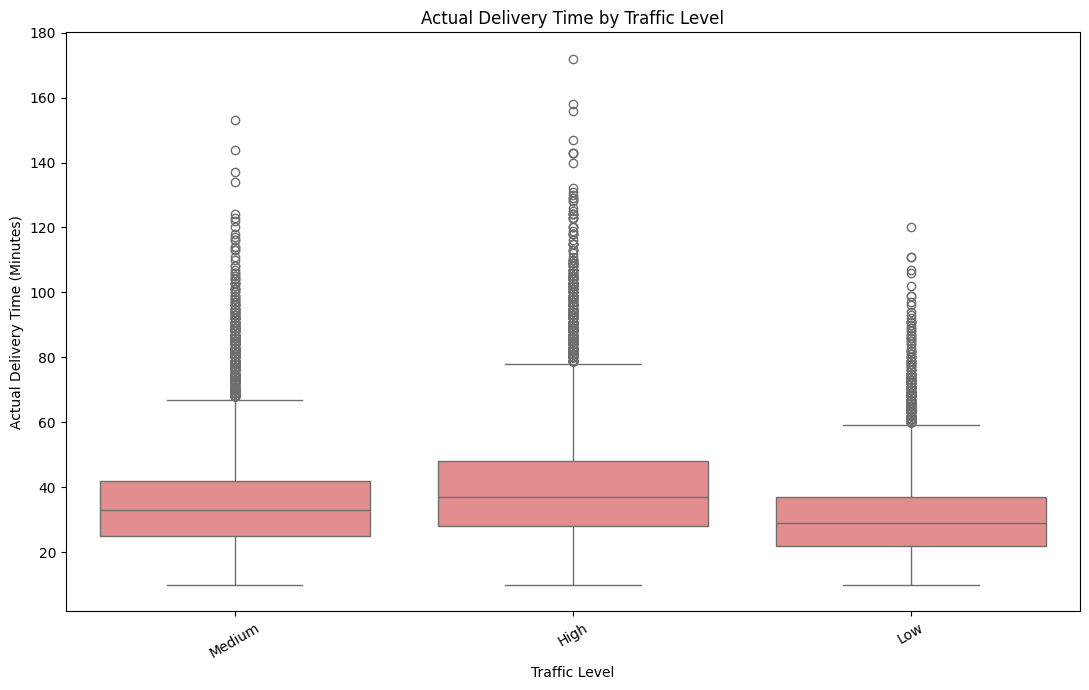

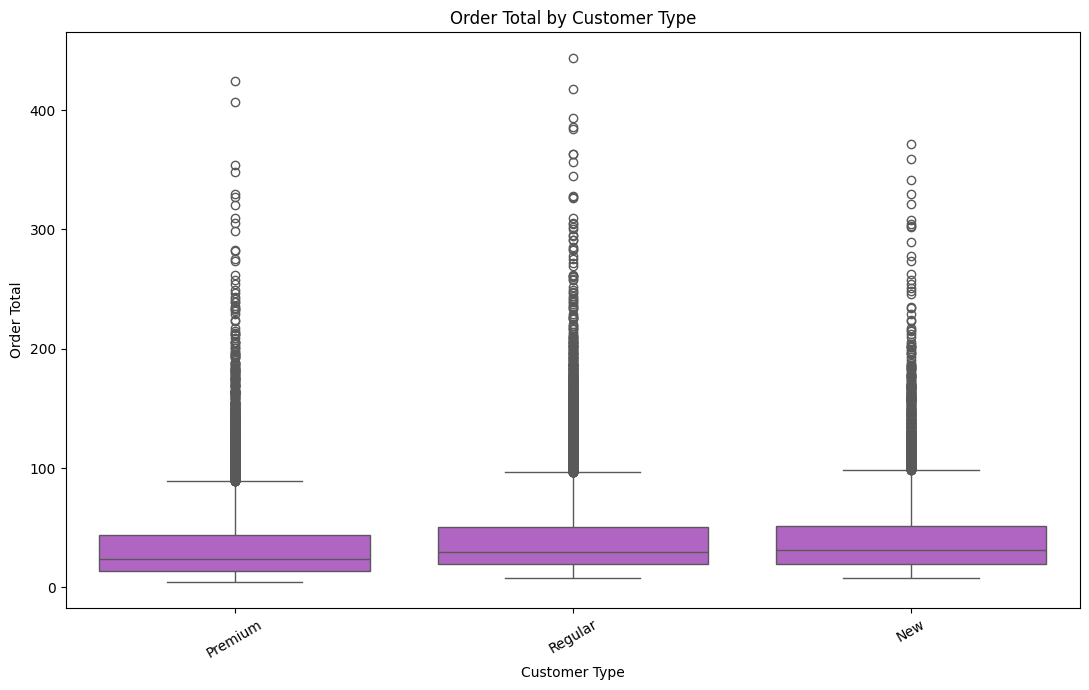

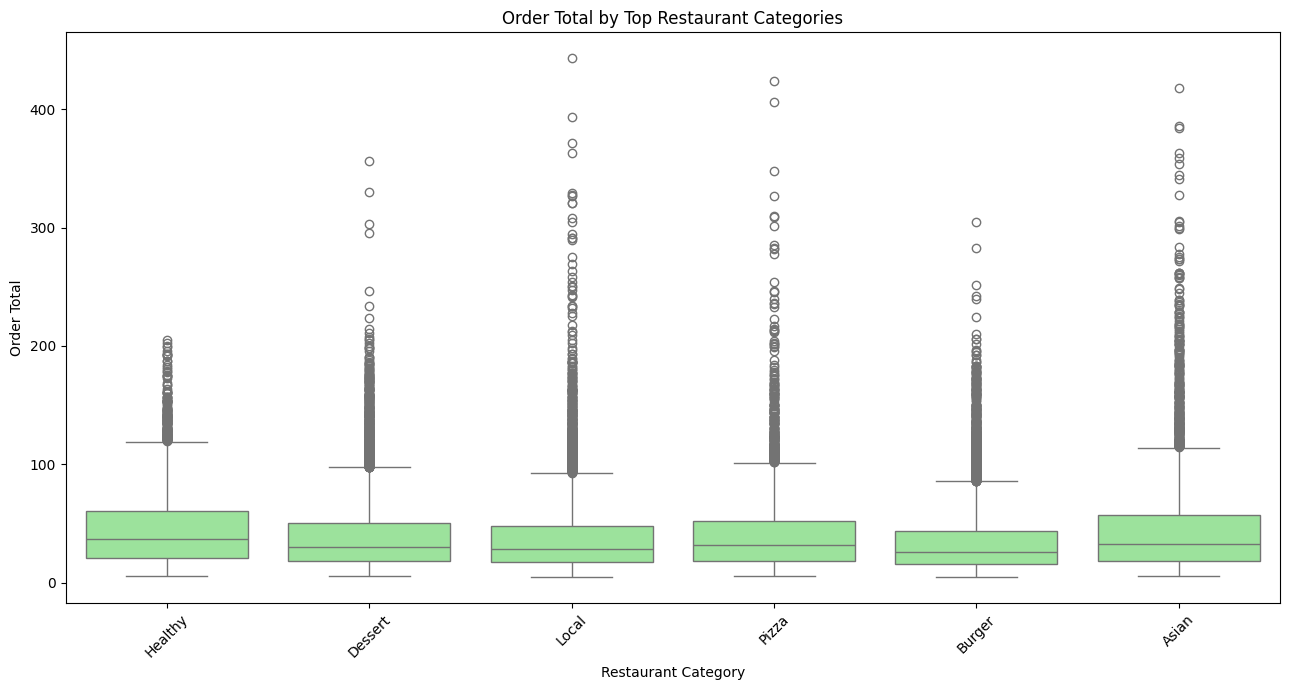

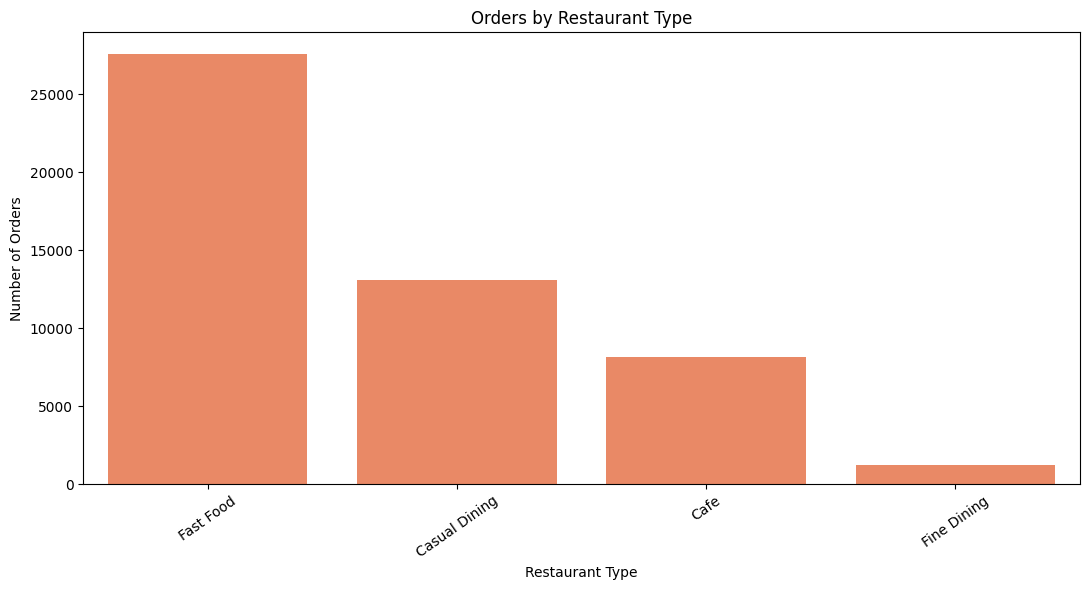

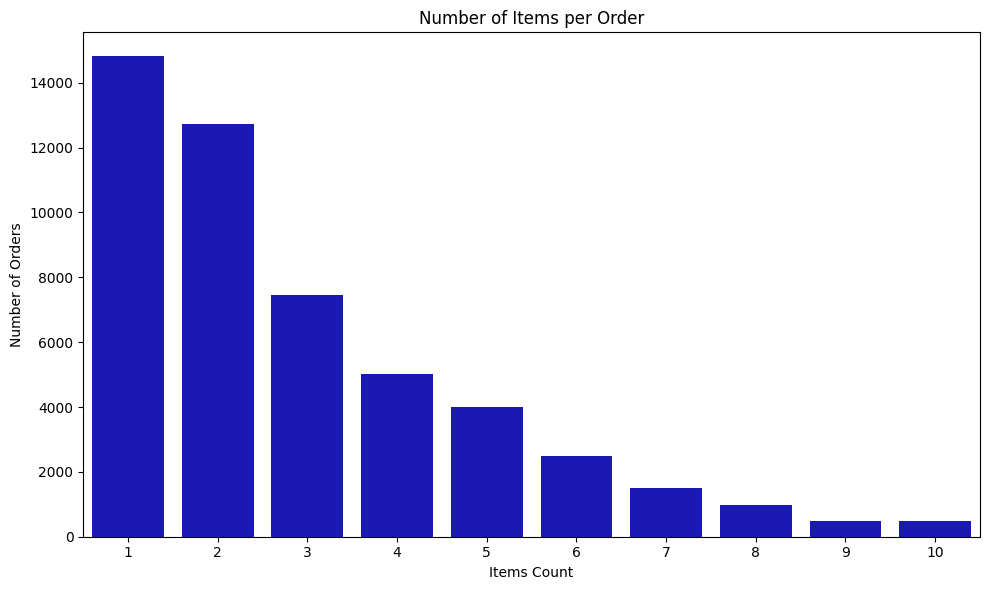

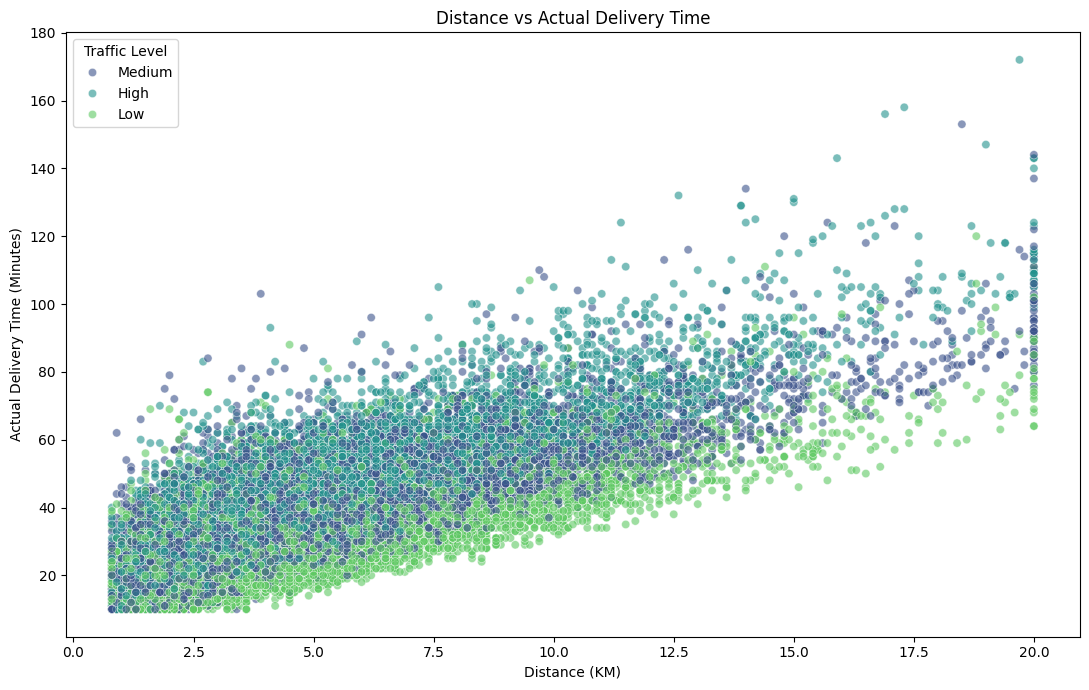

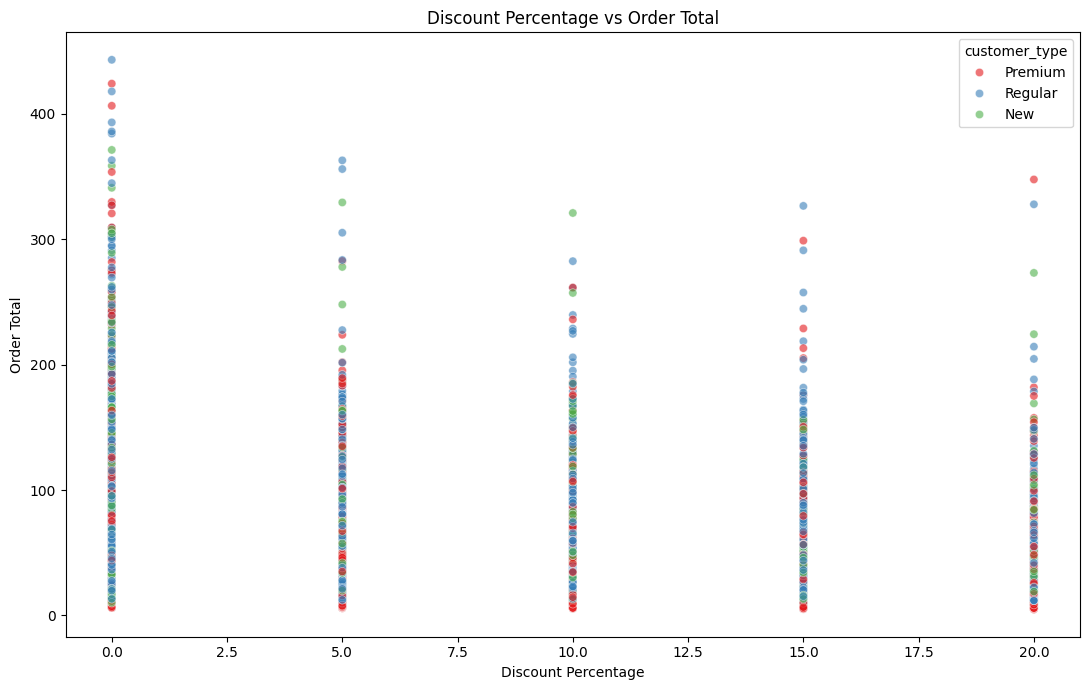

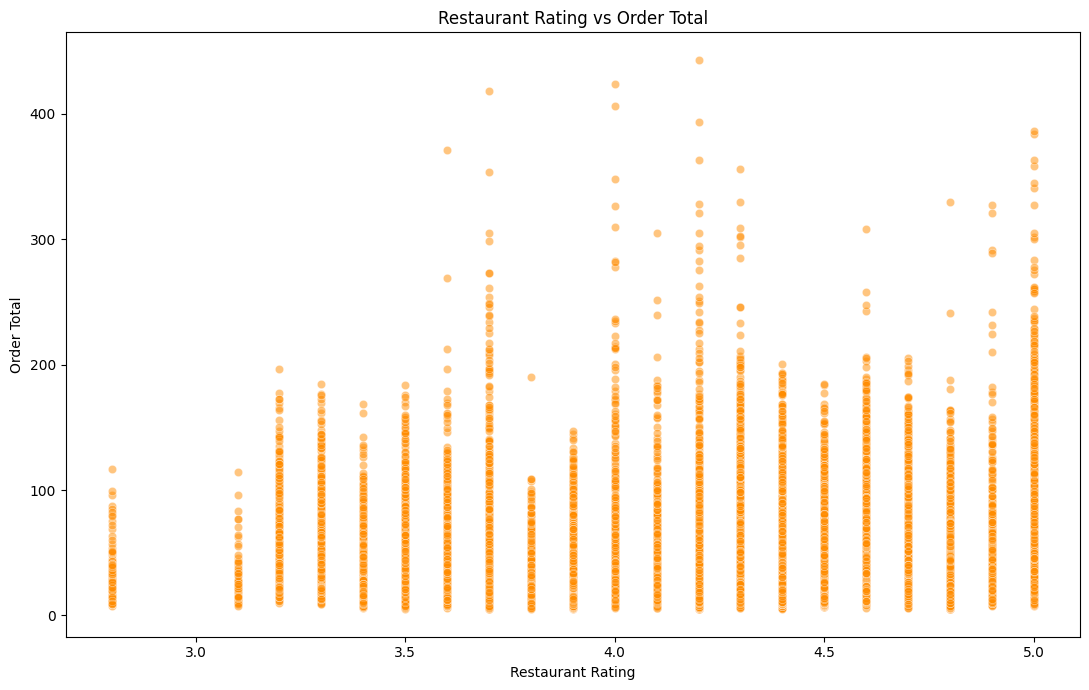

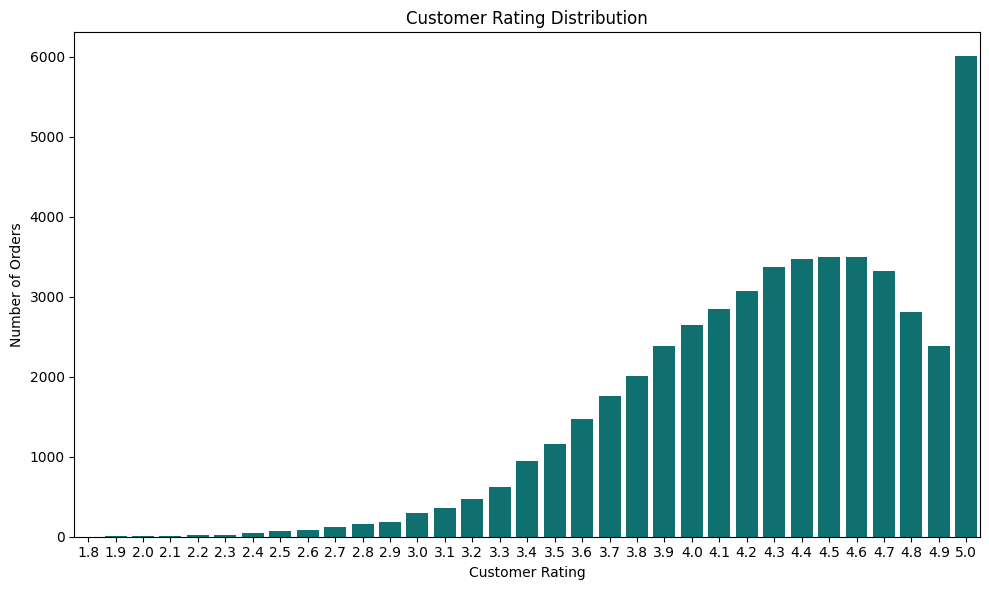

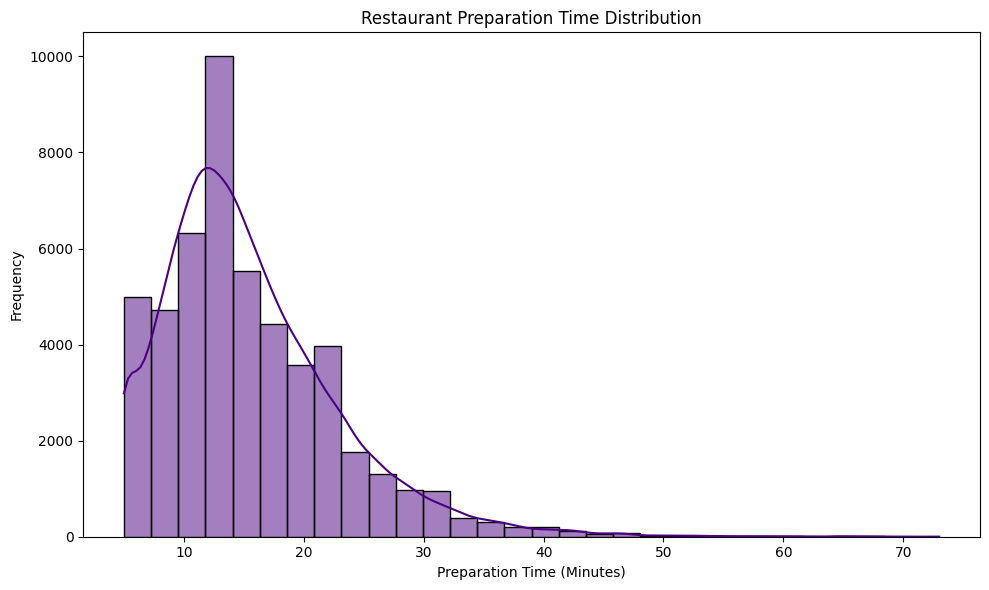

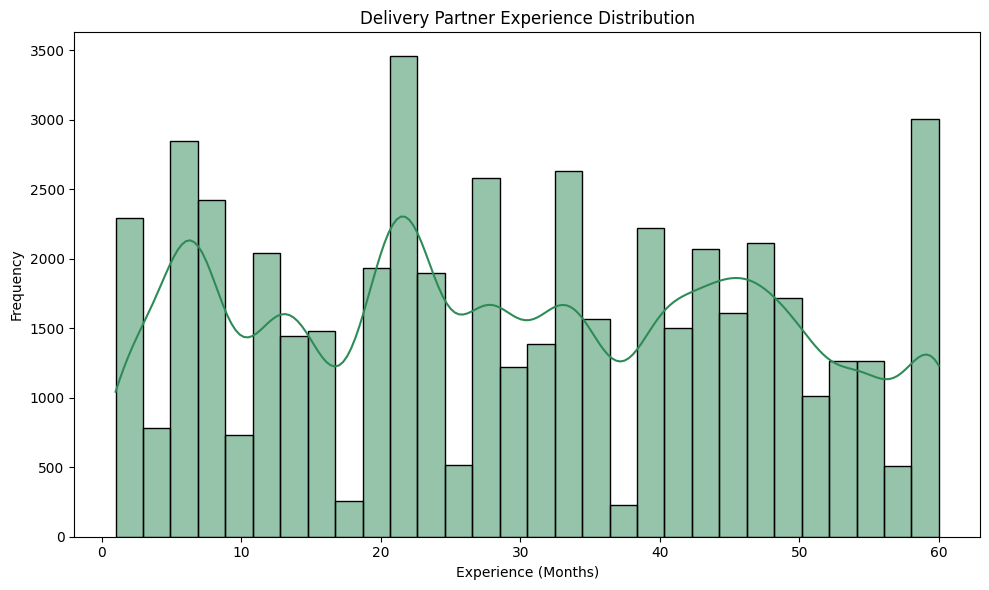

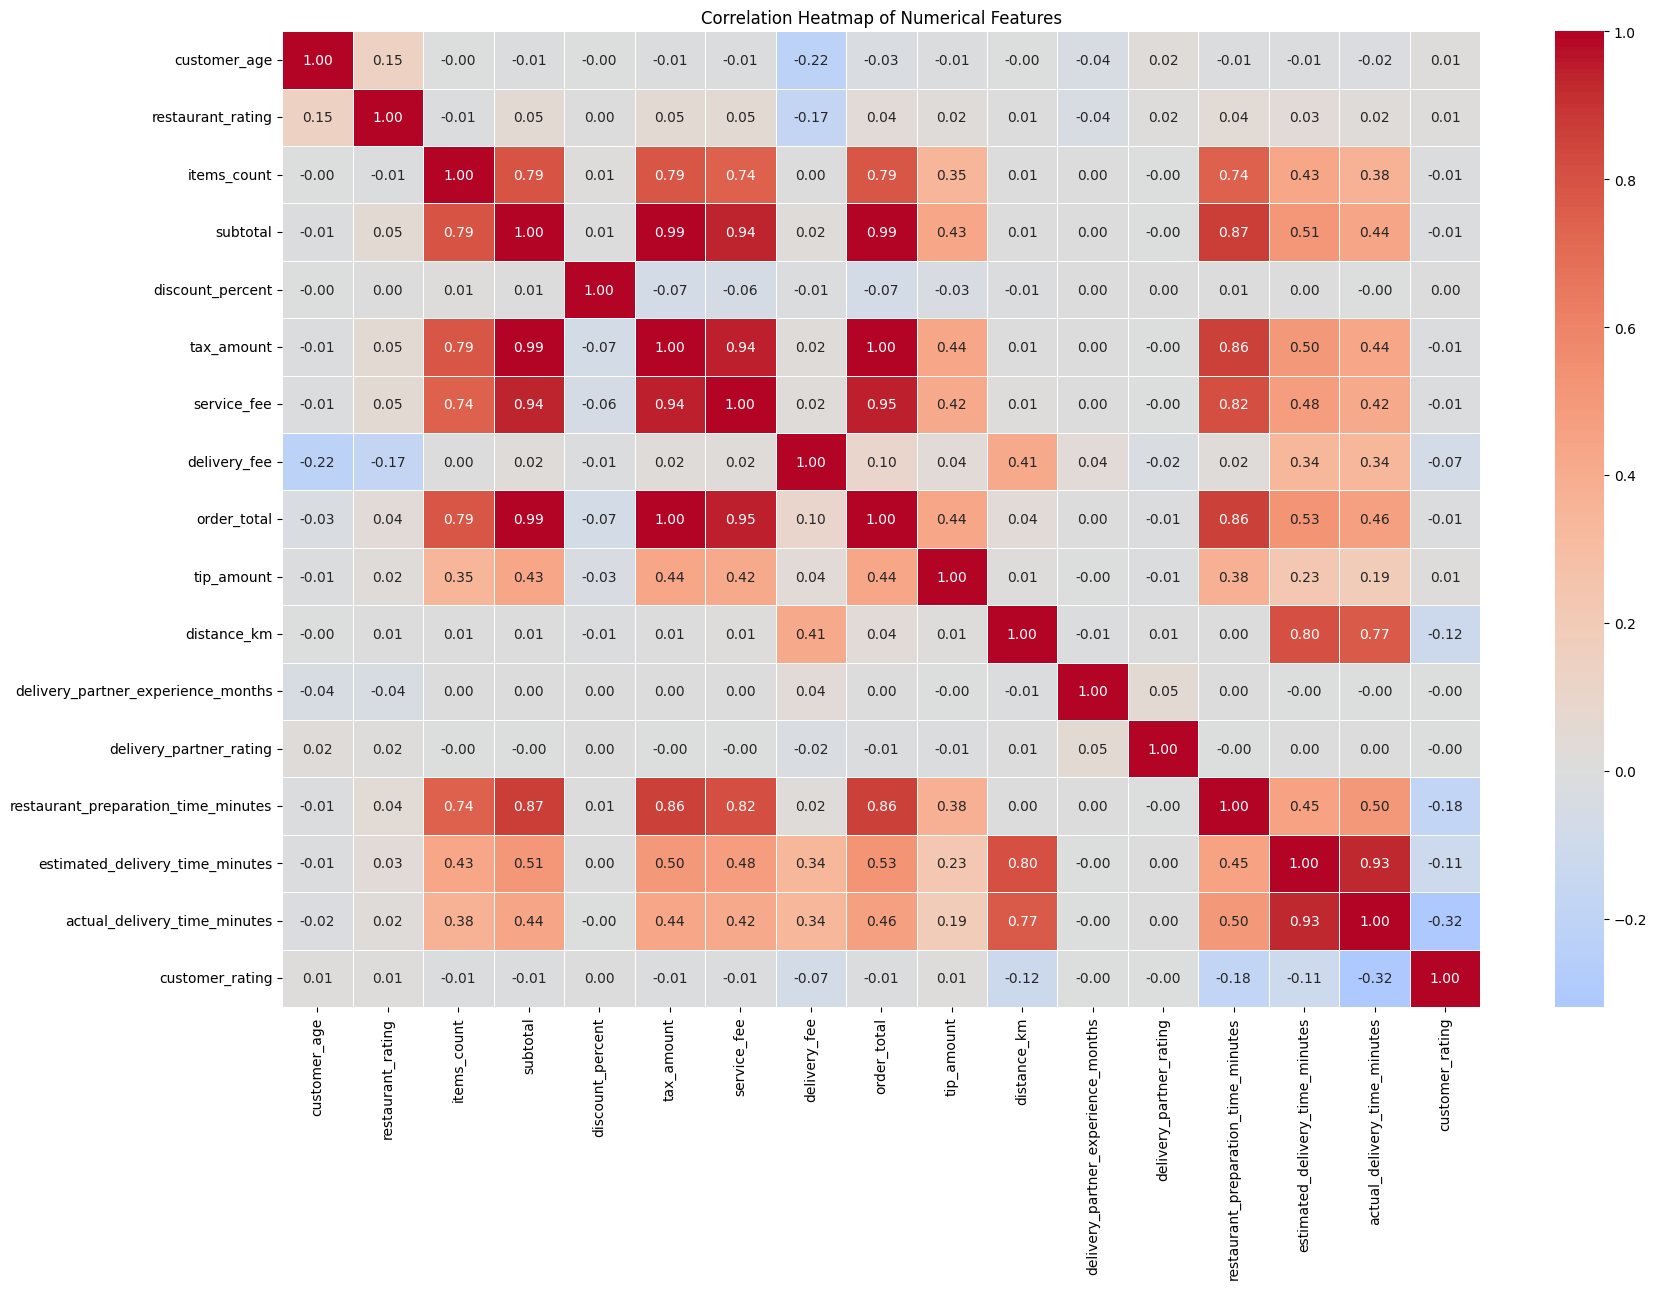

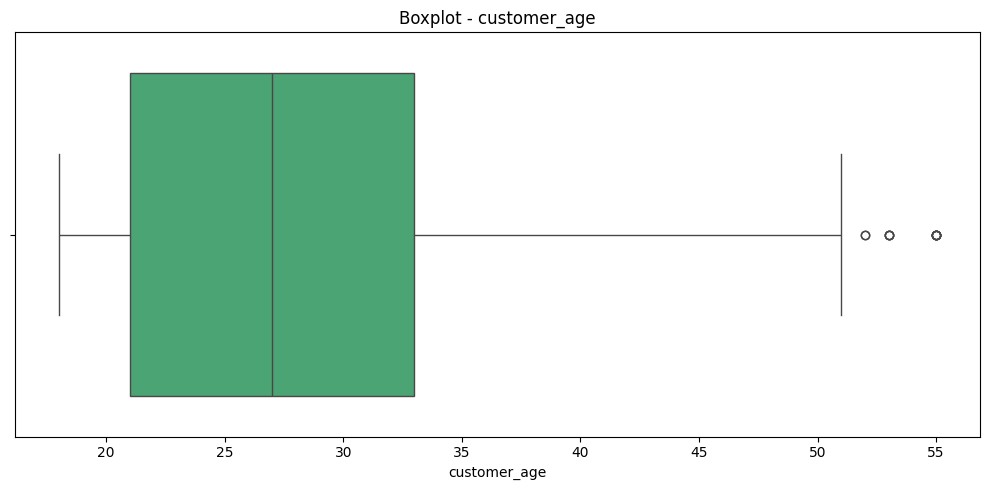

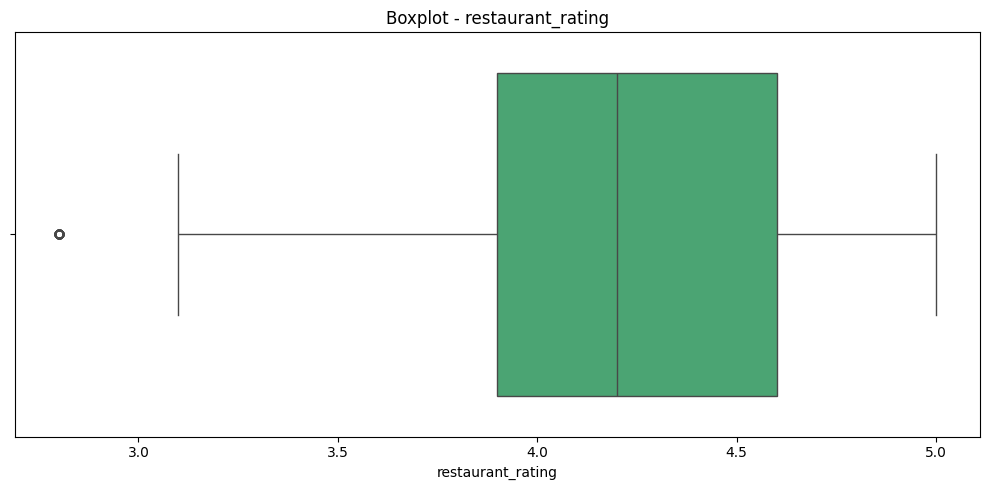

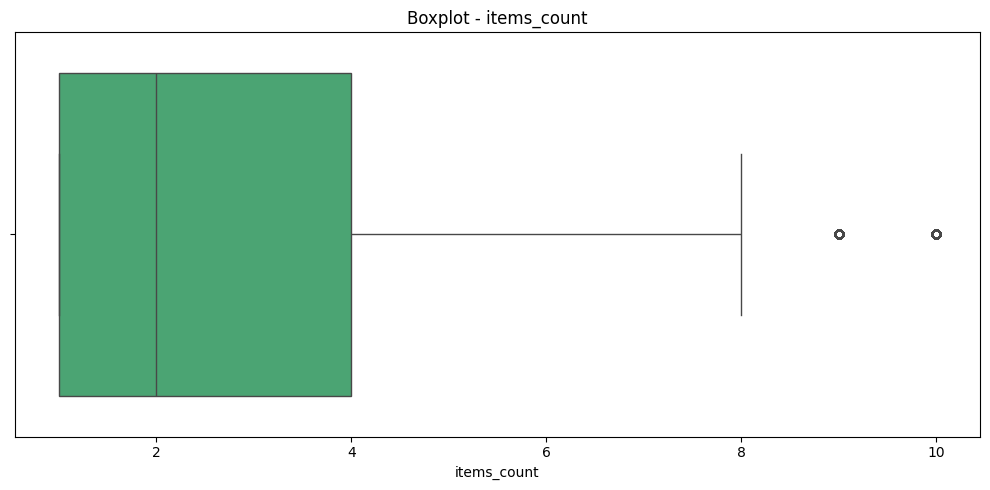

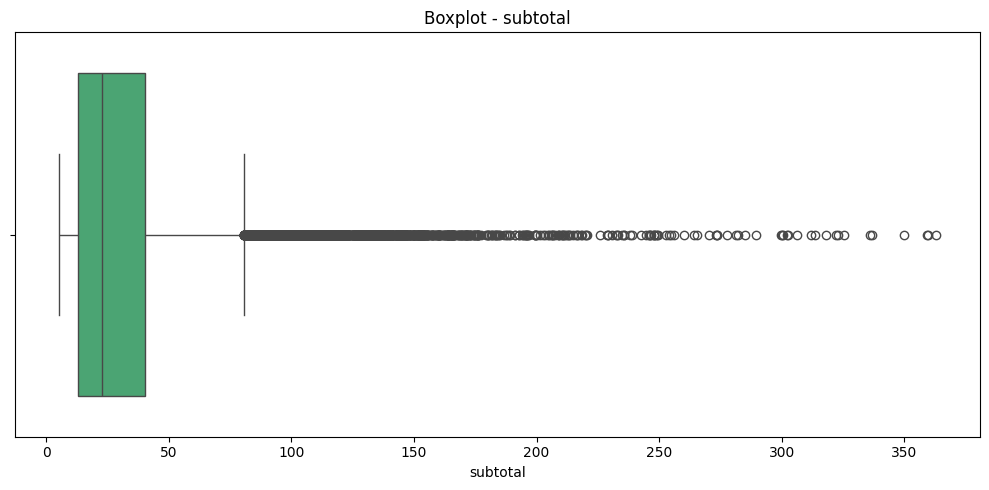

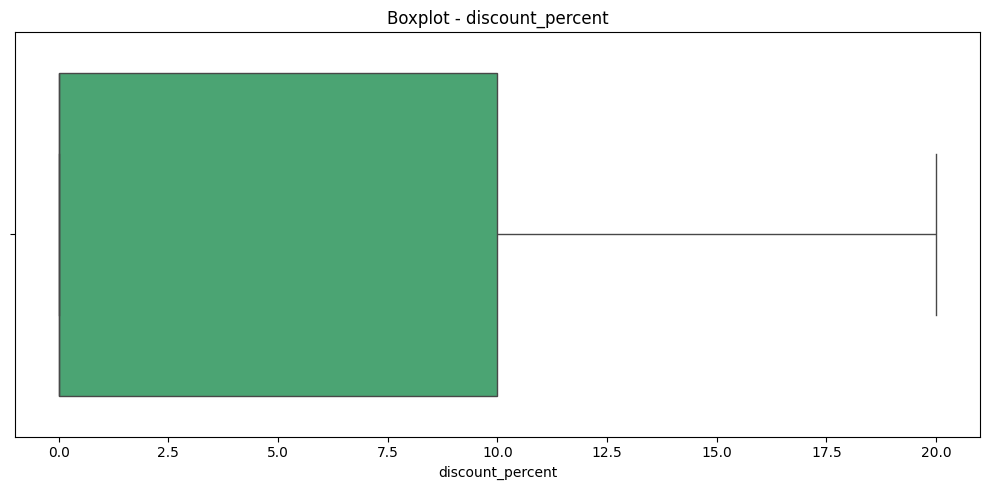

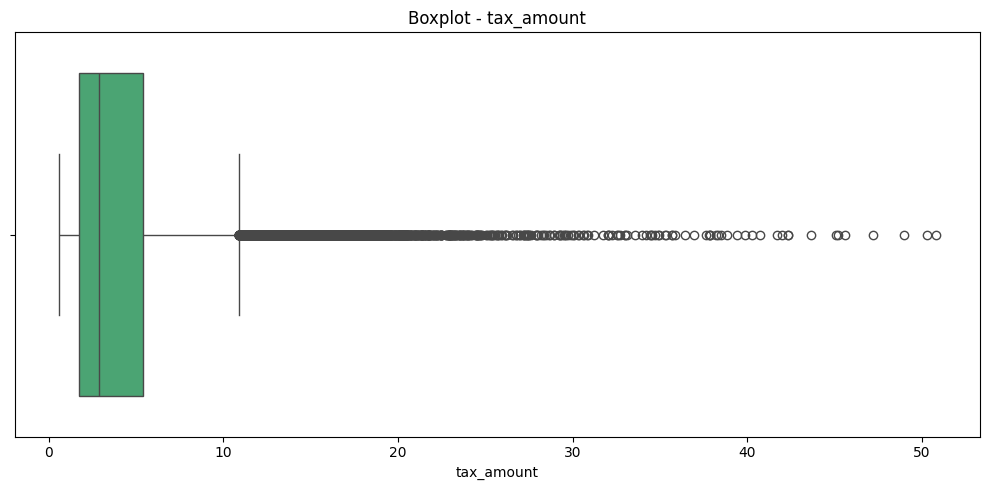

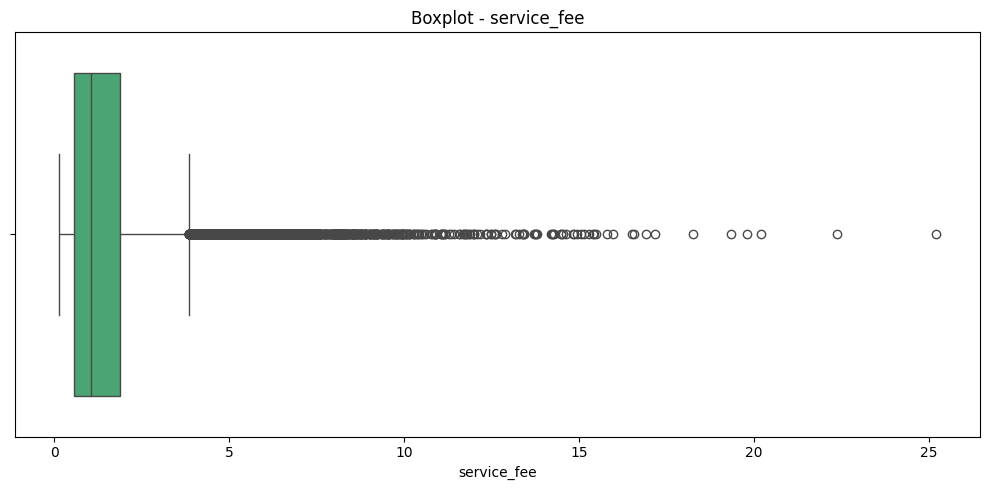

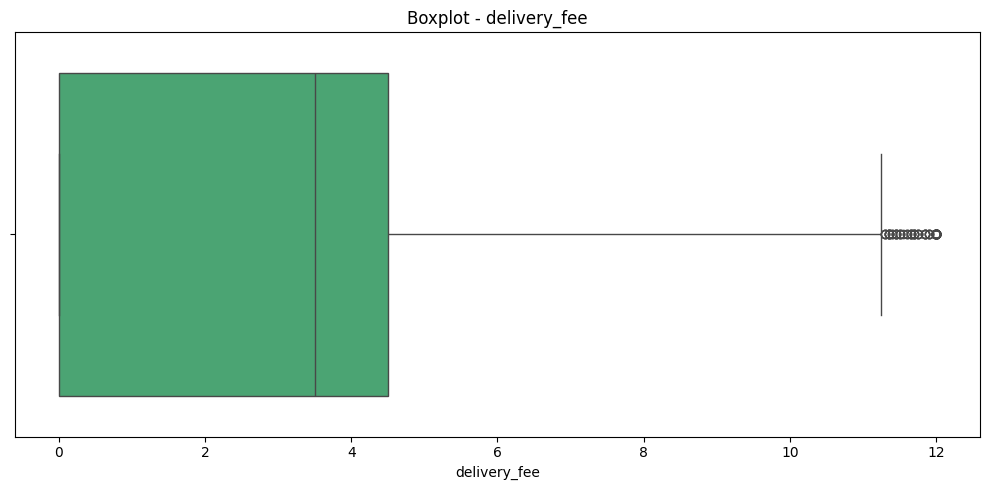

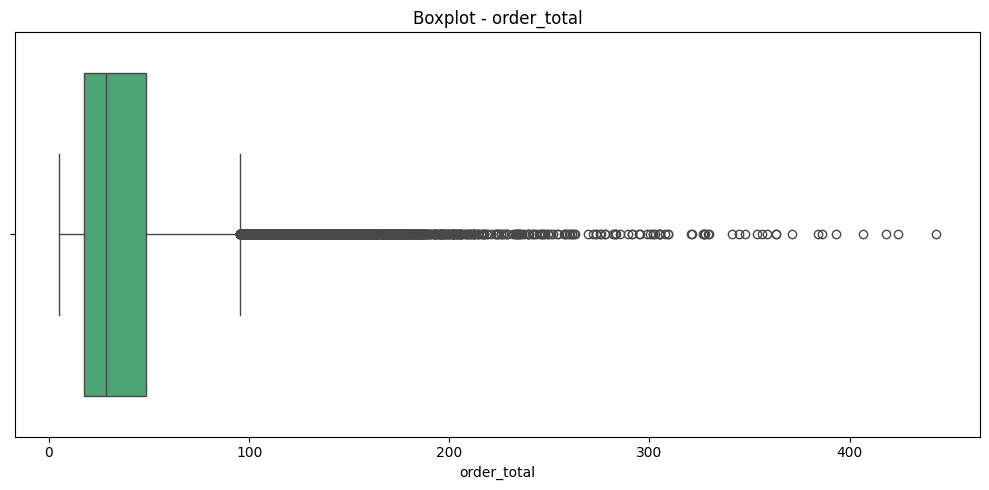

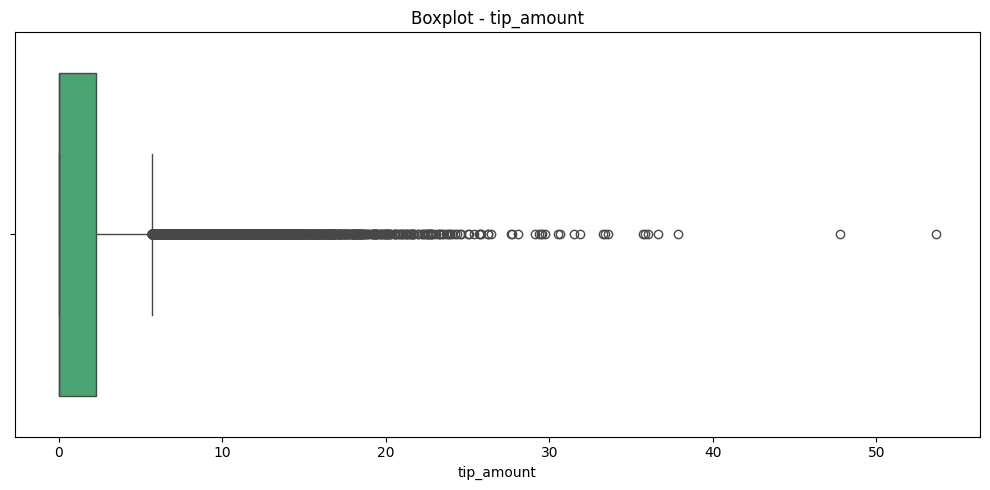

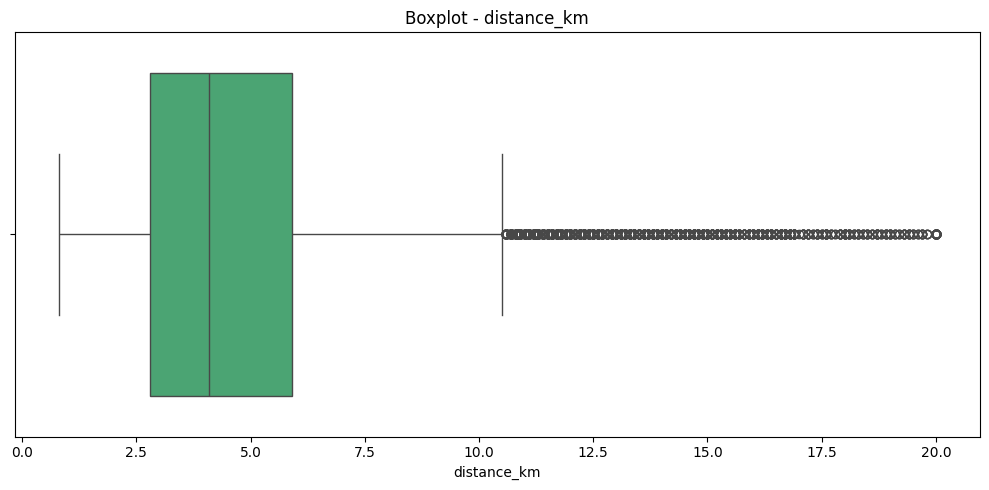

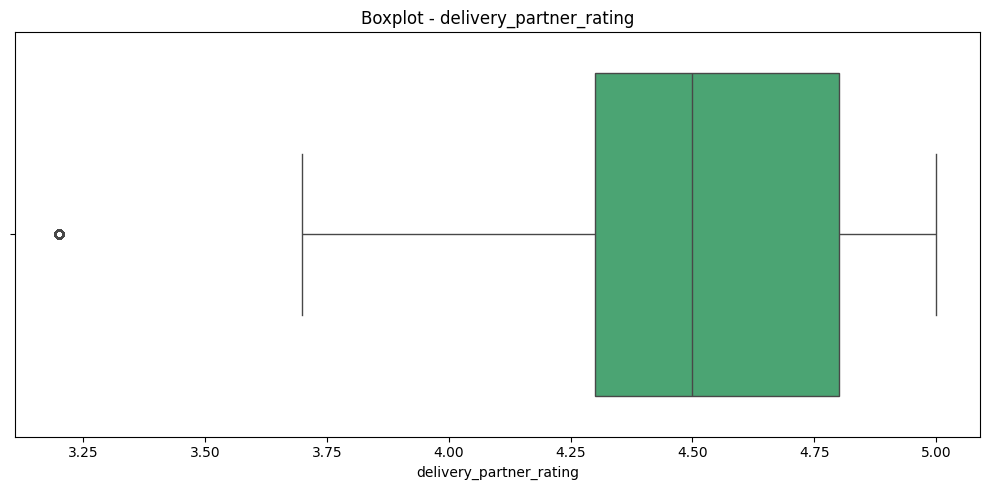

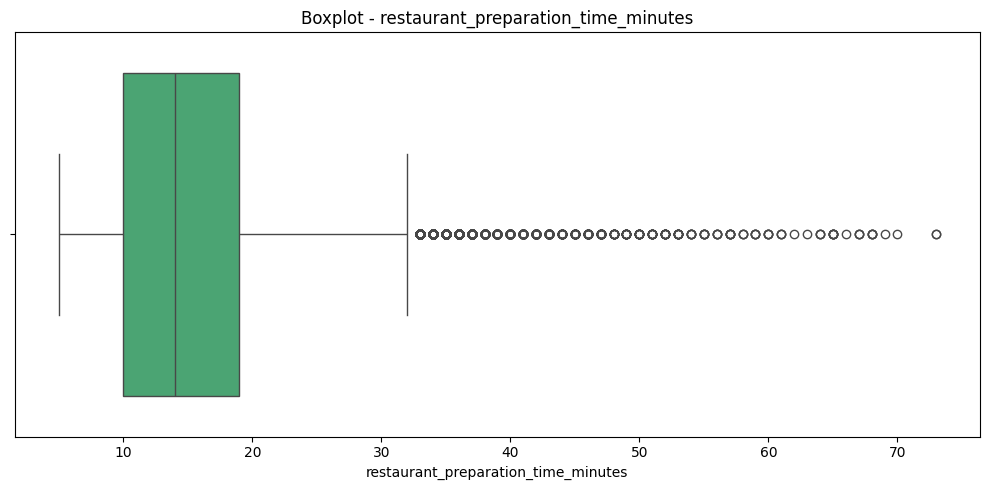

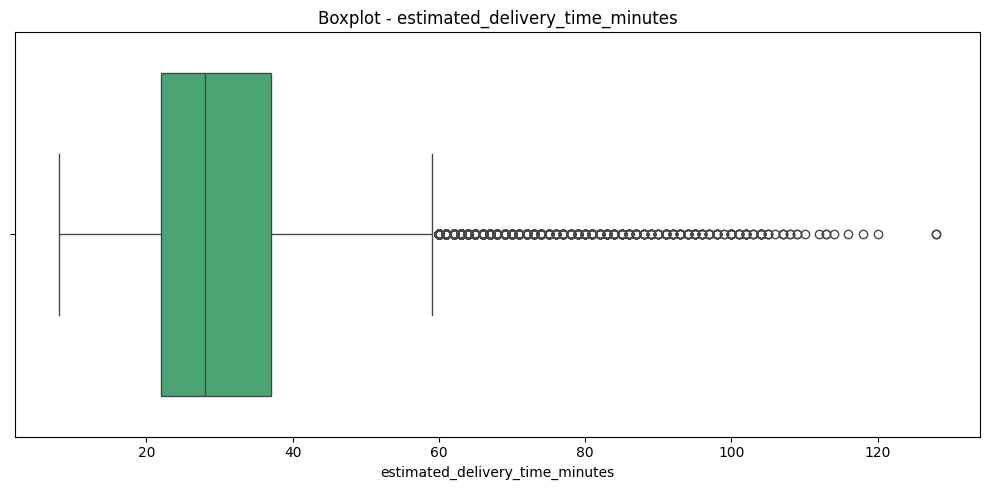

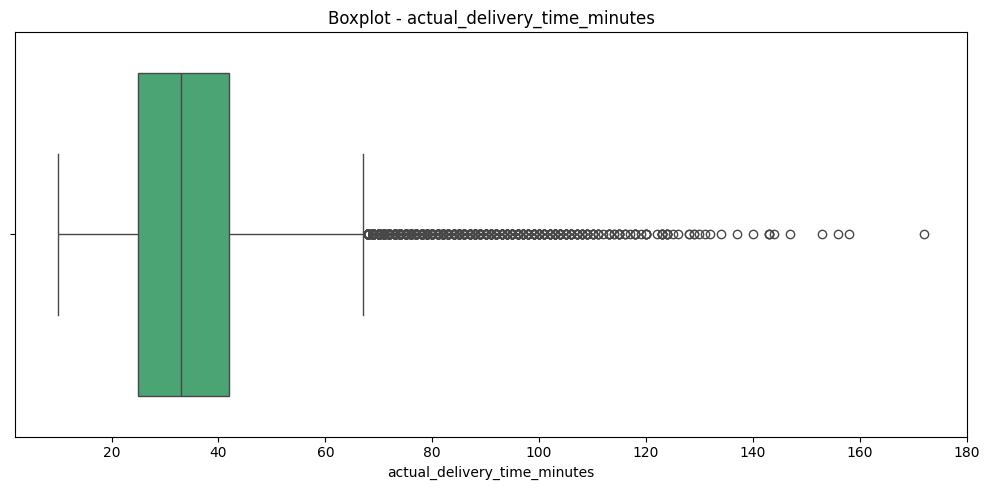

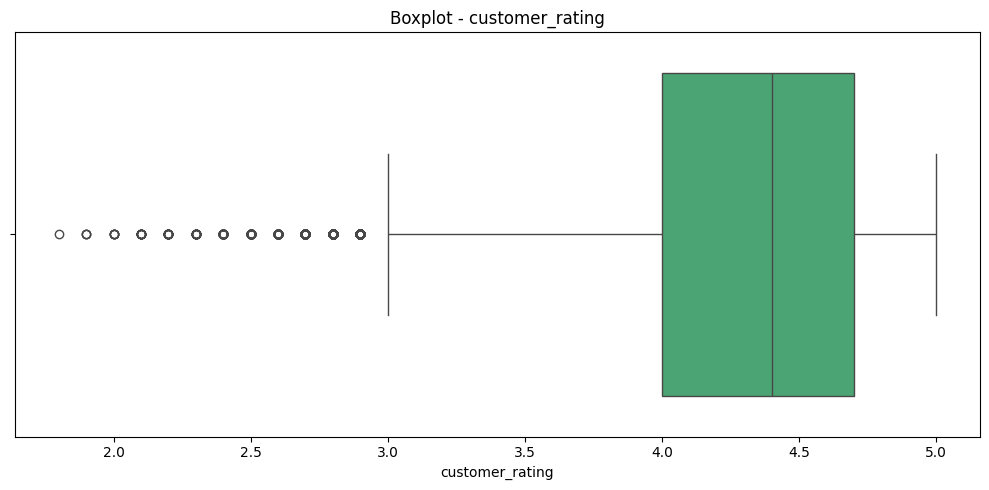

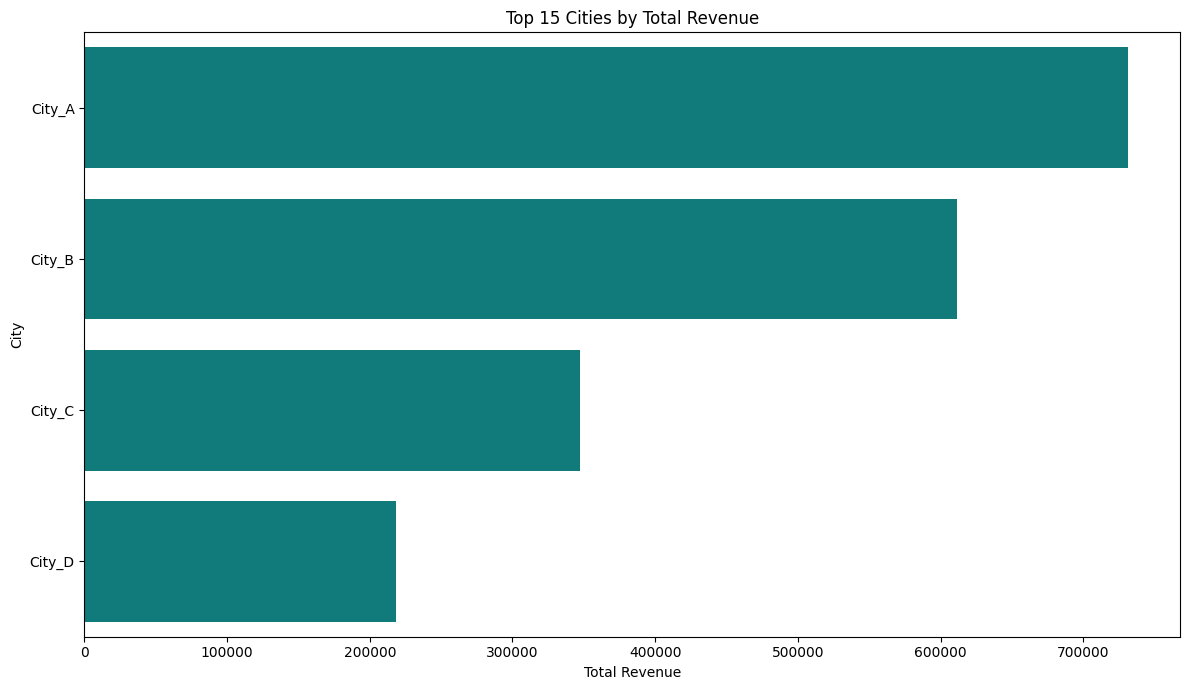

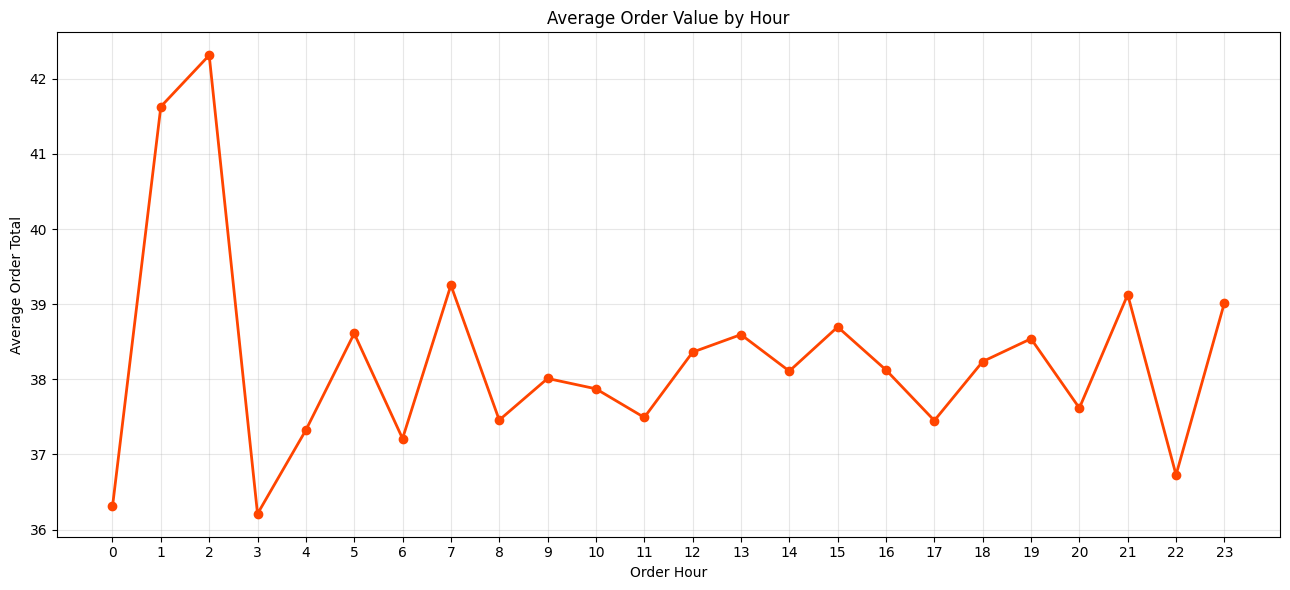

<Figure size 1100x600 with 0 Axes>

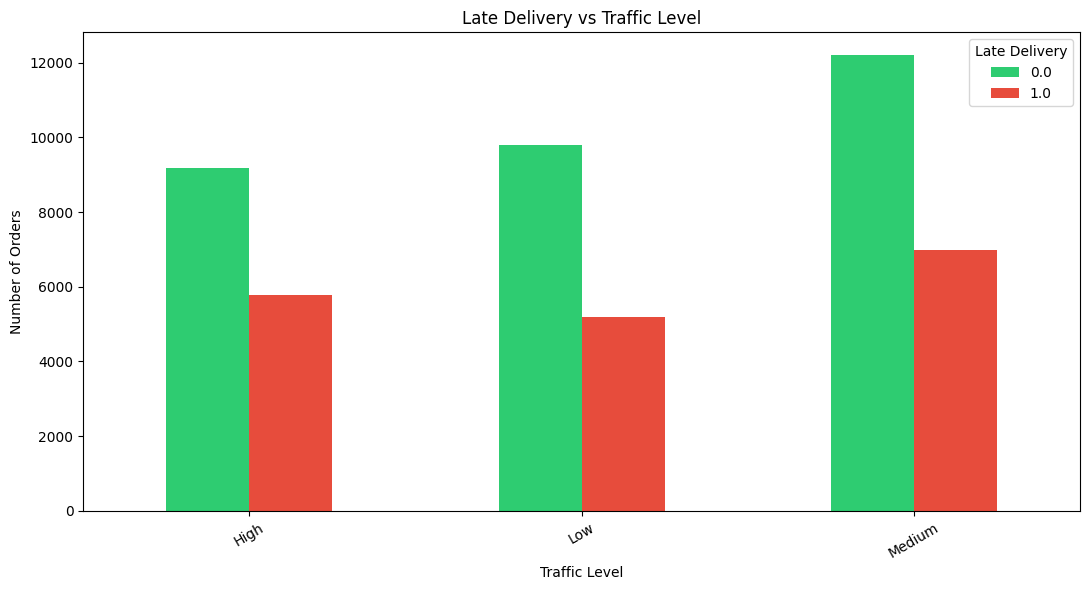

<Figure size 1100x600 with 0 Axes>

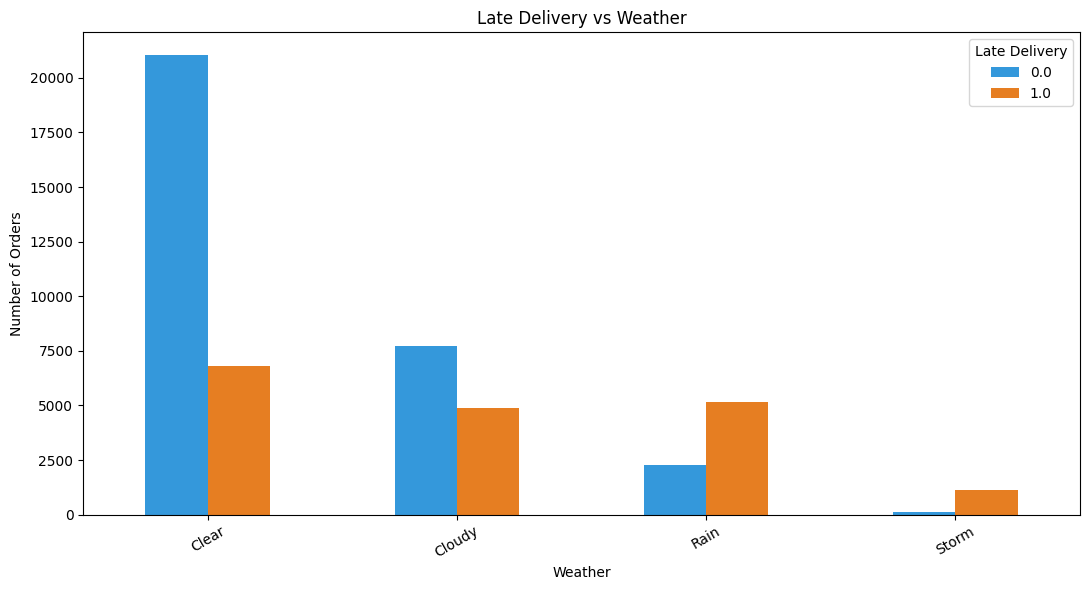

<Figure size 1200x700 with 0 Axes>

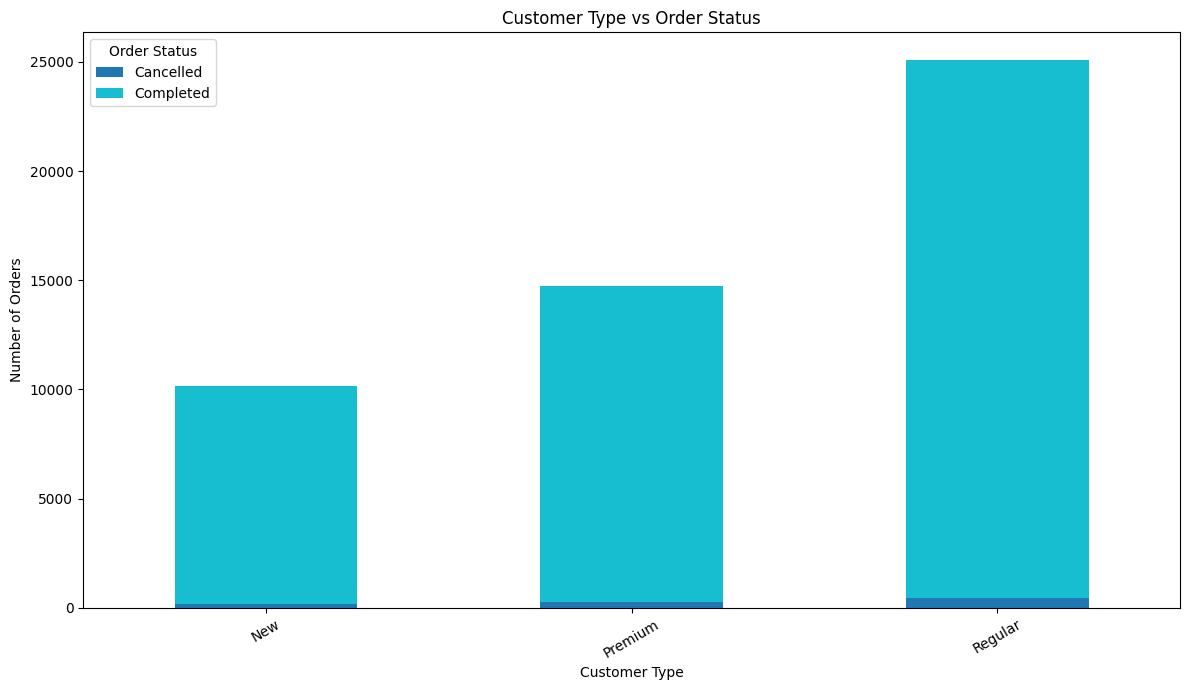

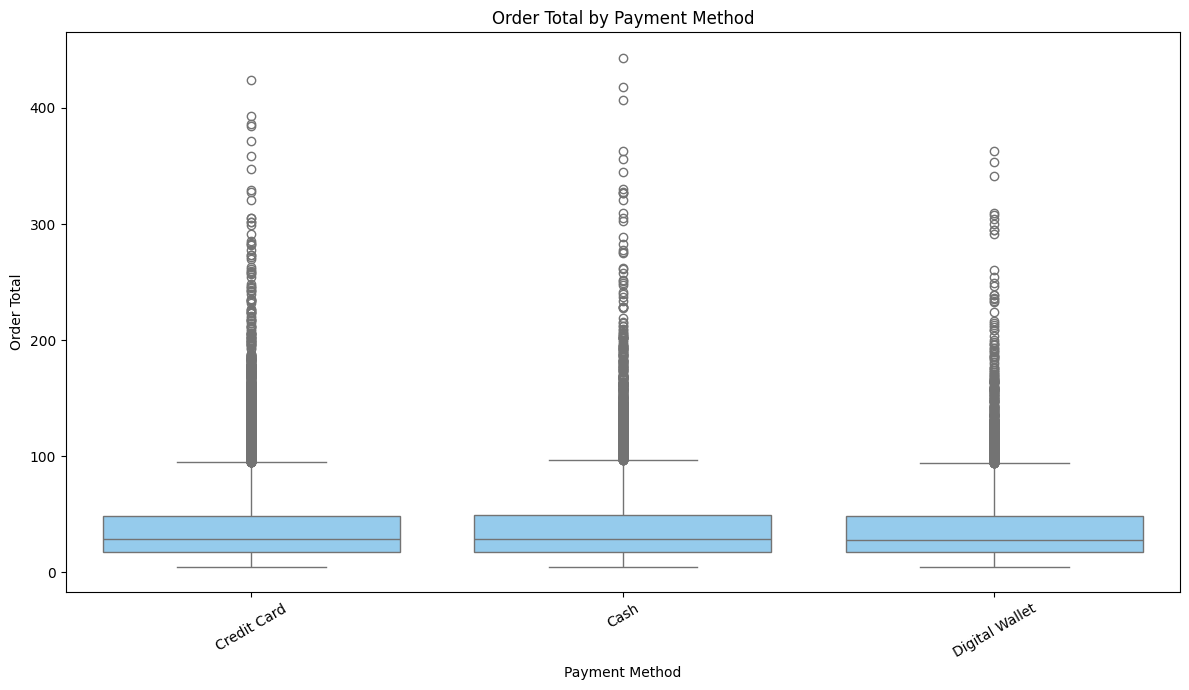

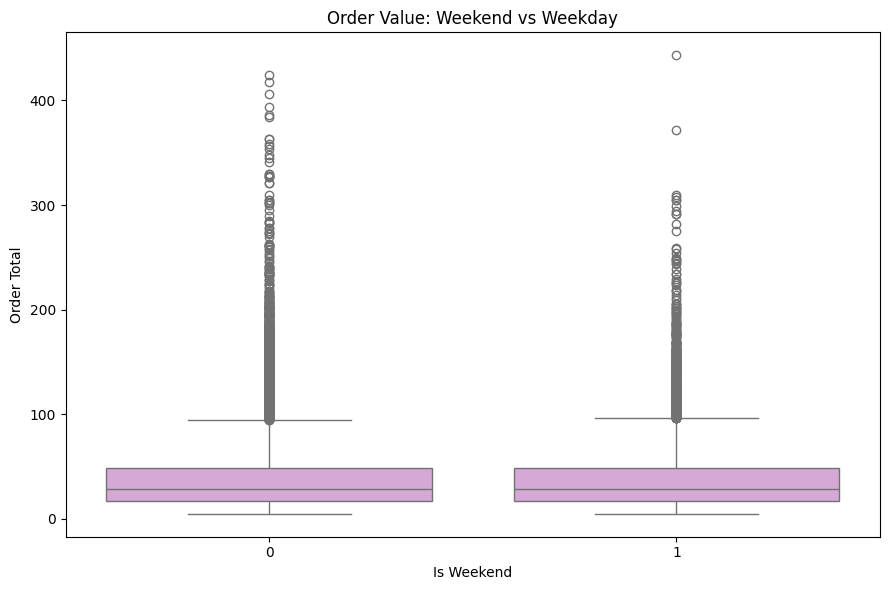

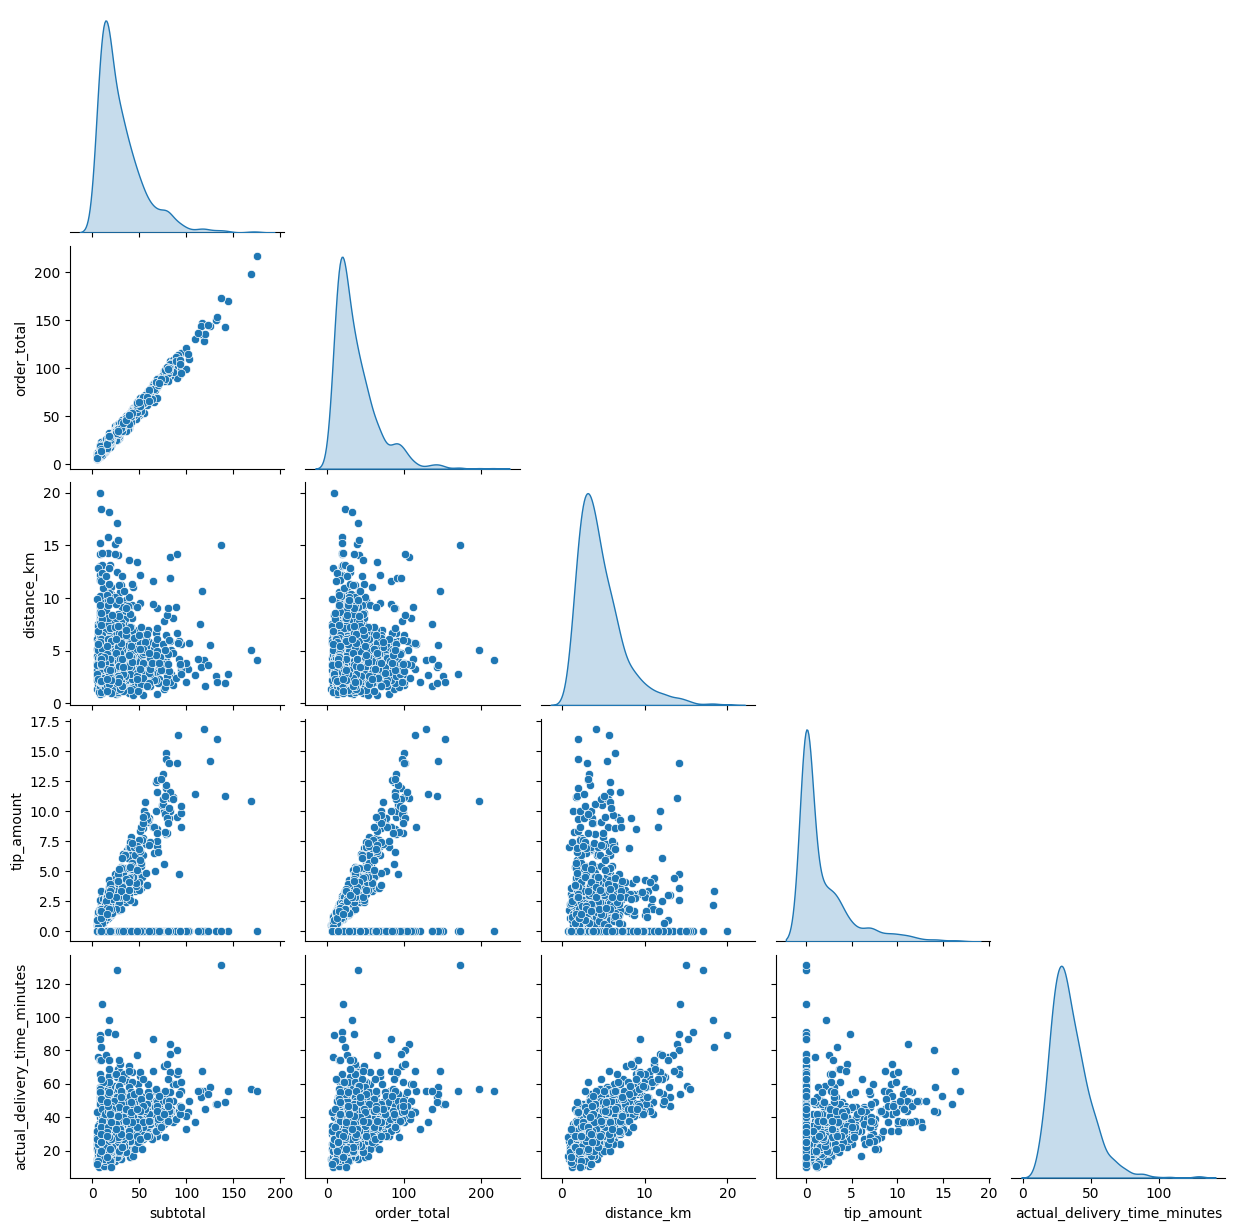


         VISUALIZATION COMPLETED
Number of Rows: 50000
Number of Columns: 37

Numerical Columns:
['order_hour', 'is_weekend', 'customer_age', 'restaurant_rating', 'items_count', 'subtotal', 'discount_percent', 'tax_amount', 'service_fee', 'delivery_fee', 'order_total', 'tip_amount', 'distance_km', 'delivery_partner_experience_months', 'delivery_partner_rating', 'restaurant_preparation_time_minutes', 'estimated_delivery_time_minutes', 'actual_delivery_time_minutes', 'late_delivery', 'customer_rating']

Categorical Columns:
['order_id', 'customer_id', 'restaurant_id', 'driver_id', 'day_of_week', 'city', 'delivery_area', 'customer_type', 'restaurant_type', 'restaurant_primary_category', 'payment_method', 'weather', 'traffic_level', 'order_status', 'cancellation_reason']

Top Order Status:
order_status
Completed    49132
Cancelled      868
Name: count, dtype: int64

Top Cities:
city
City_A    19888
City_B    14885
City_C    10178
City_D     5049
Name: count, dtype: int64

Average Order To

In [10]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())


# ============================================================
# 3. BASIC DATA INFORMATION
# ============================================================

print("\n========== DATA INFORMATION ==========")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========")
display(df.describe(include="all").T)


# ============================================================
# 4. MISSING VALUES VISUALIZATION
# ============================================================

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))

if len(missing) > 0:
    sns.barplot(
        x=missing.values,
        y=missing.index,
        color="purple"
    )
    plt.title("Missing Values by Column")
    plt.xlabel("Number of Missing Values")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()
else:
    plt.text(
        0.5, 0.5,
        "No Missing Values",
        ha="center",
        va="center",
        fontsize=18
    )
    plt.axis("off")
    plt.show()


# ============================================================
# 5. ORDER STATUS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="order_status",
    color="royalblue"
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 6. CUSTOMER TYPE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

customer_counts = df["customer_type"].value_counts()

plt.pie(
    customer_counts.values,
    labels=customer_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#FF6B6B", "#4ECDC4", "#FFD166", "#6A4C93"]
)

plt.title("Customer Type Distribution")
plt.show()


# ============================================================
# 7. RESTAURANT CATEGORY DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 7))

category_counts = (
    df["restaurant_primary_category"]
    .value_counts()
    .head(15)
)

sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    color="darkorange"
)

plt.title("Top 15 Restaurant Categories")
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant Category")
plt.tight_layout()
plt.show()


# ============================================================
# 8. PAYMENT METHOD DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

payment_counts = df["payment_method"].value_counts()

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[
        "#8E44AD",
        "#3498DB",
        "#2ECC71",
        "#F1C40F",
        "#E74C3C"
    ]
)

plt.title("Payment Method Distribution")
plt.show()


# ============================================================
# 9. CITY-WISE ORDERS
# ============================================================

city_counts = df["city"].value_counts().head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=city_counts.values,
    y=city_counts.index,
    color="teal"
)

plt.title("Top 15 Cities by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("City")
plt.tight_layout()
plt.show()


# ============================================================
# 10. DAY OF WEEK DISTRIBUTION
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_counts = df["day_of_week"].value_counts()

plt.figure(figsize=(11, 6))

sns.barplot(
    x=day_counts.index,
    y=day_counts.values,
    color="crimson"
)

plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 11. ORDERS BY HOUR
# ============================================================

hour_counts = df["order_hour"].value_counts().sort_index()

plt.figure(figsize=(13, 6))

plt.plot(
    hour_counts.index,
    hour_counts.values,
    marker="o",
    linewidth=2,
    color="darkblue"
)

plt.fill_between(
    hour_counts.index,
    hour_counts.values,
    alpha=0.2,
    color="skyblue"
)

plt.title("Orders by Hour of Day")
plt.xlabel("Order Hour")
plt.ylabel("Number of Orders")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 12. WEEKEND VS WEEKDAY
# ============================================================

weekend_counts = df["is_weekend"].value_counts()

plt.figure(figsize=(8, 6))

sns.barplot(
    x=weekend_counts.index.astype(str),
    y=weekend_counts.values,
    color="mediumseagreen"
)

plt.title("Weekend vs Weekday Orders")
plt.xlabel("Is Weekend")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


# ============================================================
# 13. ORDER TOTAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(11, 6))

sns.histplot(
    df["order_total"].dropna(),
    bins=40,
    kde=True,
    color="purple"
)

plt.title("Order Total Distribution")
plt.xlabel("Order Total")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 14. SUBTOTAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(11, 6))

sns.histplot(
    df["subtotal"].dropna(),
    bins=40,
    kde=True,
    color="green"
)

plt.title("Subtotal Distribution")
plt.xlabel("Subtotal")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 15. DISCOUNT PERCENTAGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["discount_percent"].dropna(),
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Discount Percentage Distribution")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 16. DELIVERY FEE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["delivery_fee"].dropna(),
    bins=30,
    kde=True,
    color="brown"
)

plt.title("Delivery Fee Distribution")
plt.xlabel("Delivery Fee")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 17. TIP AMOUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["tip_amount"].dropna(),
    bins=30,
    kde=True,
    color="hotpink"
)

plt.title("Tip Amount Distribution")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 18. DISTANCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["distance_km"].dropna(),
    bins=40,
    kde=True,
    color="navy"
)

plt.title("Delivery Distance Distribution")
plt.xlabel("Distance (KM)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 19. CUSTOMER AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["customer_age"].dropna(),
    bins=30,
    kde=True,
    color="darkgreen"
)

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ============================================================
# 20. RESTAURANT RATING DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["restaurant_rating"].dropna(),
    bins=20,
    kde=True,
    color="gold"
)

plt.title("Restaurant Rating Distribution")
plt.xlabel("Restaurant Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 21. DELIVERY PARTNER RATING
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["delivery_partner_rating"].dropna(),
    bins=20,
    kde=True,
    color="deepskyblue"
)

plt.title("Delivery Partner Rating Distribution")
plt.xlabel("Delivery Partner Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 22. WEATHER DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

weather_counts = df["weather"].value_counts()

sns.barplot(
    x=weather_counts.index,
    y=weather_counts.values,
    color="slateblue"
)

plt.title("Orders by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 23. TRAFFIC LEVEL DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 6))

traffic_counts = df["traffic_level"].value_counts()

sns.barplot(
    x=traffic_counts.index,
    y=traffic_counts.values,
    color="firebrick"
)

plt.title("Orders by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 24. LATE DELIVERY DISTRIBUTION
# ============================================================

late_counts = df["late_delivery"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    late_counts.values,
    labels=late_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2ECC71", "#E74C3C"]
)

plt.title("Late Delivery Distribution")
plt.show()


# ============================================================
# 25. ESTIMATED VS ACTUAL DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["estimated_delivery_time_minutes"],
    df["actual_delivery_time_minutes"],
    alpha=0.4,
    color="darkviolet"
)

max_value = max(
    df["estimated_delivery_time_minutes"].max(),
    df["actual_delivery_time_minutes"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    color="black"
)

plt.title("Estimated vs Actual Delivery Time")
plt.xlabel("Estimated Delivery Time (Minutes)")
plt.ylabel("Actual Delivery Time (Minutes)")
plt.tight_layout()
plt.show()


# ============================================================
# 26. DELIVERY TIME BY TRAFFIC LEVEL
# ============================================================

plt.figure(figsize=(11, 7))

sns.boxplot(
    data=df,
    x="traffic_level",
    y="actual_delivery_time_minutes",
    color="lightcoral"
)

plt.title("Actual Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Actual Delivery Time (Minutes)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 27. ORDER TOTAL BY CUSTOMER TYPE
# ============================================================

plt.figure(figsize=(11, 7))

sns.boxplot(
    data=df,
    x="customer_type",
    y="order_total",
    color="mediumorchid"
)

plt.title("Order Total by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Order Total")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 28. ORDER TOTAL BY RESTAURANT CATEGORY
# ============================================================

top_categories = (
    df["restaurant_primary_category"]
    .value_counts()
    .head(10)
    .index
)

temp = df[
    df["restaurant_primary_category"].isin(top_categories)
]

plt.figure(figsize=(13, 7))

sns.boxplot(
    data=temp,
    x="restaurant_primary_category",
    y="order_total",
    color="lightgreen"
)

plt.title("Order Total by Top Restaurant Categories")
plt.xlabel("Restaurant Category")
plt.ylabel("Order Total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 29. ORDERS BY RESTAURANT TYPE
# ============================================================

restaurant_type_counts = (
    df["restaurant_type"]
    .value_counts()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=restaurant_type_counts.index,
    y=restaurant_type_counts.values,
    color="coral"
)

plt.title("Orders by Restaurant Type")
plt.xlabel("Restaurant Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


# ============================================================
# 30. ITEMS COUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="items_count",
    color="mediumblue"
)

plt.title("Number of Items per Order")
plt.xlabel("Items Count")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


# ============================================================
# 31. DISTANCE VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="distance_km",
    y="actual_delivery_time_minutes",
    hue="traffic_level",
    palette="viridis",
    alpha=0.6
)

plt.title("Distance vs Actual Delivery Time")
plt.xlabel("Distance (KM)")
plt.ylabel("Actual Delivery Time (Minutes)")
plt.legend(title="Traffic Level")
plt.tight_layout()
plt.show()


# ============================================================
# 32. DISCOUNT VS ORDER TOTAL
# ============================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="discount_percent",
    y="order_total",
    hue="customer_type",
    palette="Set1",
    alpha=0.6
)

plt.title("Discount Percentage vs Order Total")
plt.xlabel("Discount Percentage")
plt.ylabel("Order Total")
plt.tight_layout()
plt.show()


# ============================================================
# 33. RESTAURANT RATING VS ORDER TOTAL
# ============================================================

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="restaurant_rating",
    y="order_total",
    color="darkorange",
    alpha=0.5
)

plt.title("Restaurant Rating vs Order Total")
plt.xlabel("Restaurant Rating")
plt.ylabel("Order Total")
plt.tight_layout()
plt.show()


# ============================================================
# 34. CUSTOMER RATING DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="customer_rating",
    color="teal"
)

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()


# ============================================================
# 35. PREPARATION TIME DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["restaurant_preparation_time_minutes"].dropna(),
    bins=30,
    kde=True,
    color="indigo"
)

plt.title("Restaurant Preparation Time Distribution")
plt.xlabel("Preparation Time (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 36. DELIVERY PARTNER EXPERIENCE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["delivery_partner_experience_months"].dropna(),
    bins=30,
    kde=True,
    color="seagreen"
)

plt.title("Delivery Partner Experience Distribution")
plt.xlabel("Experience (Months)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


# ============================================================
# 37. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "customer_age",
    "restaurant_rating",
    "items_count",
    "subtotal",
    "discount_percent",
    "tax_amount",
    "service_fee",
    "delivery_fee",
    "order_total",
    "tip_amount",
    "distance_km",
    "delivery_partner_experience_months",
    "delivery_partner_rating",
    "restaurant_preparation_time_minutes",
    "estimated_delivery_time_minutes",
    "actual_delivery_time_minutes",
    "customer_rating"
]

numeric_columns = [
    col for col in numeric_columns
    if col in df.columns
]

corr = df[numeric_columns].corr()

plt.figure(figsize=(18, 13))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


# ============================================================
# 38. NUMERICAL FEATURES BOXPLOTS
# ============================================================

box_columns = [
    "customer_age",
    "restaurant_rating",
    "items_count",
    "subtotal",
    "discount_percent",
    "tax_amount",
    "service_fee",
    "delivery_fee",
    "order_total",
    "tip_amount",
    "distance_km",
    "delivery_partner_rating",
    "restaurant_preparation_time_minutes",
    "estimated_delivery_time_minutes",
    "actual_delivery_time_minutes",
    "customer_rating"
]

box_columns = [
    col for col in box_columns
    if col in df.columns
]

for col in box_columns:

    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=df[col],
        color="mediumseagreen"
    )

    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 39. TOP CITIES BY REVENUE
# ============================================================

city_revenue = (
    df.groupby("city")["order_total"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=city_revenue.values,
    y=city_revenue.index,
    color="darkcyan"
)

plt.title("Top 15 Cities by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("City")
plt.tight_layout()
plt.show()


# ============================================================
# 40. AVERAGE ORDER VALUE BY HOUR
# ============================================================

hour_avg = (
    df.groupby("order_hour")["order_total"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(13, 6))

plt.plot(
    hour_avg.index,
    hour_avg.values,
    marker="o",
    linewidth=2,
    color="orangered"
)

plt.title("Average Order Value by Hour")
plt.xlabel("Order Hour")
plt.ylabel("Average Order Total")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 41. LATE DELIVERY VS TRAFFIC
# ============================================================

late_traffic = pd.crosstab(
    df["traffic_level"],
    df["late_delivery"]
)

plt.figure(figsize=(11, 6))

late_traffic.plot(
    kind="bar",
    figsize=(11, 6),
    color=["#2ECC71", "#E74C3C"]
)

plt.title("Late Delivery vs Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.legend(title="Late Delivery")
plt.tight_layout()
plt.show()


# ============================================================
# 42. LATE DELIVERY VS WEATHER
# ============================================================

late_weather = pd.crosstab(
    df["weather"],
    df["late_delivery"]
)

plt.figure(figsize=(11, 6))

late_weather.plot(
    kind="bar",
    figsize=(11, 6),
    color=["#3498DB", "#E67E22"]
)

plt.title("Late Delivery vs Weather")
plt.xlabel("Weather")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.legend(title="Late Delivery")
plt.tight_layout()
plt.show()


# ============================================================
# 43. CUSTOMER TYPE VS ORDER STATUS
# ============================================================

customer_status = pd.crosstab(
    df["customer_type"],
    df["order_status"]
)

plt.figure(figsize=(12, 7))

customer_status.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7),
    colormap="tab10"
)

plt.title("Customer Type vs Order Status")
plt.xlabel("Customer Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.legend(title="Order Status")
plt.tight_layout()
plt.show()


# ============================================================
# 44. PAYMENT METHOD VS ORDER TOTAL
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="payment_method",
    y="order_total",
    color="lightskyblue"
)

plt.title("Order Total by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Order Total")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# ============================================================
# 45. WEEKEND VS ORDER VALUE
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="is_weekend",
    y="order_total",
    color="plum"
)

plt.title("Order Value: Weekend vs Weekday")
plt.xlabel("Is Weekend")
plt.ylabel("Order Total")
plt.tight_layout()
plt.show()


# ============================================================
# 46. PAIRPLOT
# ============================================================

pair_columns = [
    "subtotal",
    "order_total",
    "distance_km",
    "tip_amount",
    "actual_delivery_time_minutes"
]

pair_columns = [
    col for col in pair_columns
    if col in df.columns
]

# Sample data to make pairplot faster
pair_sample = df[pair_columns].dropna().sample(
    min(1000, len(df)),
    random_state=42
)

sns.pairplot(
    pair_sample,
    diag_kind="kde",
    corner=True
)

plt.show()


# ============================================================
# 47. FINAL DATASET SUMMARY
# ============================================================

print("\n==========================================")
print("         VISUALIZATION COMPLETED")
print("==========================================")

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nNumerical Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Columns:")
print(df.select_dtypes(include="object").columns.tolist())

print("\nTop Order Status:")
print(df["order_status"].value_counts().head())

print("\nTop Cities:")
print(df["city"].value_counts().head())

print("\nAverage Order Total:",
      round(df["order_total"].mean(), 2))

print("Average Delivery Time:",
      round(df["actual_delivery_time_minutes"].mean(), 2))

print("Average Distance:",
      round(df["distance_km"].mean(), 2))

print("\n==========================================")
print("       END OF VISUALIZATION")
print("==========================================")

## Data cleaning

In [11]:
# Data Cleaning and Preprocessing

print('Checking for missing values in each column:')
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# If missing values are discovered and are common across many notebooks,
# consider using iterative imputation or domain-specific logic to resolve.

# For this analysis, fill missing numeric values with median and categorical with mode
for col in df.columns:
    if df[col].dtype in [np.float64, np.int64]:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
    else:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)

# Confirm that no missing values remain
assert df.isnull().sum().sum() == 0, 'There are still missing values in the DataFrame'
print('Missing values handled successfully.')

# Convert numerical columns that are read as objects if possible
# For example, restaurant_rating might be numeric
df['restaurant_rating'] = pd.to_numeric(df['restaurant_rating'], errors='coerce')
df['order_total'] = pd.to_numeric(df['order_total'], errors='coerce')

print('Data cleaning completed. Data types:')
print(df.dtypes)

Checking for missing values in each column:
tip_amount                        868
actual_delivery_time_minutes      868
late_delivery                     868
cancellation_reason             49132
customer_rating                   868
dtype: int64
Missing values handled successfully.
Data cleaning completed. Data types:
order_id                                       object
customer_id                                    object
restaurant_id                                  object
driver_id                                      object
order_timestamp                        datetime64[ns]
order_date                             datetime64[ns]
order_hour                                      int64
day_of_week                                    object
is_weekend                                      int64
city                                           object
delivery_area                                  object
customer_age                                    int64
customer_type                  

## Feature engineering


In [12]:
# Predictive Modeling: Using Logistic Regression to predict whether an order is delivered late

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# For the purpose of prediction, we assume 'late_delivery' is a binary variable (0: On Time, 1: Late)
# If not already binary, you may need to transform it accordingly.
df['late_delivery'] = df['late_delivery'].apply(lambda x: 1 if x >= 1 else 0)

# Choose a subset of features that might influence late delivery
features = ['order_hour', 'customer_age', 'items_count', 'subtotal', 'distance_km', 
            'delivery_partner_experience_months', 'restaurant_preparation_time_minutes']

X = df[features]
y = df['late_delivery']

# Create dummy variables for categorical features if needed (in this subset all are numeric)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print('Prediction Accuracy of Late Delivery Predictor:', acc)

# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.clf()

# Plot ROC Curve
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.clf()

print('Predictive modeling complete.')

Prediction Accuracy of Late Delivery Predictor: 0.7614
Predictive modeling complete.


<Figure size 600x500 with 0 Axes>

<Figure size 800x600 with 0 Axes>

## Thank you..pls upvote!!!!!!!!!!!